# Baseline Modelling and Evaluation – Case D (AIOps KPI: da403e4e3f87c9e0)

## Tier 0–1 Baselines (Heuristics, Classical) with Validation-Only Thresholding and Reproducible Artefacts

This notebook implements the baseline modelling and evaluation pipeline for Case Study D (AIOps KPI). It uses the canonical processed dataset produced during preprocessing and applies a consistent leakage-safe protocol: models are trained on the training split, thresholds are selected using validation only, and final performance is reported on the held-out test split. Outputs are saved as reproducible artefacts (configs, thresholds, predictions, metrics, and diagnostic figures) to support downstream comparison and dissertation reporting.

Objectives:

- Train Tier 0–1 baseline methods under consistent windowing and feature rules.

- Generate anomaly scores for validation and test, then convert scores to predictions using a validation-selected threshold.

- Report point-wise and event/window-level metrics, with drift-aware diagnostics where applicable.

- Save a complete artefact trail for each run and append summary results to a master results log.

## Step 1 - Define project root, input path, and create a run folder


In [21]:
from pathlib import Path
from datetime import datetime

# Project layout: the notebook lives in "masters/notebooks/", so the project root is the parent folder ("masters/")
project_root = Path.cwd().parent

# Standard processed dataset for the pilot case (AIOps KPI)
processed_file = project_root / "data" / "processed" / "aiops_kpi" / "aiops_kpi_full.csv"

# Create the run folder once per kernel session (reuse if the setup cell is re-run)
if "run_dir" not in globals():
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = project_root / "results" / "aiops_kpi" / "runs" / run_id

    (run_dir / "predictions").mkdir(parents=True, exist_ok=False)
    (run_dir / "metrics").mkdir(parents=True, exist_ok=False)
    (run_dir / "figures").mkdir(parents=True, exist_ok=False)

print("Project root:", project_root)
print("Processed file:", processed_file)
print("Run directory:", run_dir)

# Safety check: stop early if the standard input file is not found
if not processed_file.exists():
    raise FileNotFoundError(f"Processed file not found: {processed_file}")


Project root: /Users/nandipha/Desktop/masters
Processed file: /Users/nandipha/Desktop/masters/data/processed/aiops_kpi/aiops_kpi_full.csv
Run directory: /Users/nandipha/Desktop/masters/results/aiops_kpi/runs/20260108_170724


This step sets the project root to the parent folder of `notebooks/`, builds the standard processed-data path for the AIOps KPI case, and creates a timestamped run directory under `results/` so artefacts from this run do not overwrite previous runs.


## Step 2 - Load the standard processed dataset and verify the schema


In [22]:
import pandas as pd

# Load the standard processed dataset for the pilot case
df = pd.read_csv(processed_file)

# Parse the time column and sort by time (this enforces a clean time order)
df["time"] = pd.to_datetime(df["time"], errors="raise")
df = df.sort_values("time").reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", list(df.columns))
print("\nTime span:", df["time"].min(), "→", df["time"].max())

# Confirm the expected standard columns exist
expected_cols = [
    "time", "value", "value_scaled", "is_anomaly",
    "hour_of_day", "day_of_week", "is_weekend",
    "split", "case_study"
]

missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

print("\nSchema check: OK")
print("Case study labels:", df["case_study"].unique())
print("Split labels:", df["split"].unique())


Rows: 129035
Columns: ['time', 'value', 'value_scaled', 'is_anomaly', 'hour_of_day', 'day_of_week', 'is_weekend', 'split', 'case_study']

Time span: 2017-04-30 16:00:00 → 2017-07-31 04:29:00

Schema check: OK
Case study labels: ['aiops_kpi']
Split labels: ['train' 'validation' 'test']


This step loads the standard processed dataset for the AIOps KPI pilot case, ensures the time column is valid and correctly ordered, and verifies that the expected standard columns are present. These checks confirm the dataset is ready for split summaries, windowing, and baseline modelling.


## Step 3 - Summarise splits and confirm anomaly distribution


This step produces a split summary table for the training, validation, and test segments. It reports time span, row counts, anomaly counts, and anomaly proportions per split. This confirms that the dataset segmentation is suitable for leakage-safe modelling (train for fitting, validation for threshold selection, test for final reporting).


In [24]:
# Basic split summary: time span, row counts, anomaly counts, anomaly proportion
split_summary = (
    df.groupby("split")
      .agg(
          start_time=("time", "min"),
          end_time=("time", "max"),
          rows=("time", "size"),
          anomaly_points=("is_anomaly", "sum")
      )
      .reset_index()
)

split_summary["anomaly_ratio"] = split_summary["anomaly_points"] / split_summary["rows"]

# Add simple duration fields (useful for sanity checking)
split_summary["duration_hours"] = (split_summary["end_time"] - split_summary["start_time"]).dt.total_seconds() / 3600

# Sort in the natural modelling order
order = pd.CategoricalDtype(categories=["train", "validation", "test"], ordered=True)
split_summary["split"] = split_summary["split"].astype(order)
split_summary = split_summary.sort_values("split").reset_index(drop=True)

split_summary


,split,start_time,end_time,rows,anomaly_points,anomaly_ratio,duration_hours
0,train,2017-04-30 16:00:00,2017-06-15 23:59:00,63999,563,0.008797,1111.983333
1,validation,2017-06-16 00:00:00,2017-06-27 23:59:00,17268,97,0.005617,287.983333
2,test,2017-06-28 00:00:00,2017-07-31 04:29:00,47768,7006,0.146667,796.483333


#### Step 3 - Interpretation of split summary (AIOps KPI)

The split summary confirms a strongly non-stationary anomaly structure across time:

- **Training segment** (2017-04-30 16:00 to 2017-06-15 23:59) contains **63,999** points with **563** anomalies, giving an anomaly ratio of **0.008797 (~0.88%)**. This is consistent with a mostly-normal learning segment suitable for fitting baseline behaviour.

- **Validation segment** (2017-06-16 00:00 to 2017-06-27 23:59) contains **17,268** points with **97** anomalies, giving an anomaly ratio of **0.005617 (~0.56%)**. This provides some labelled anomalies for selecting thresholds without using test information.

- **Test segment** (2017-06-28 00:00 to 2017-07-31 04:29) contains **47,768** points with **7,006** anomalies, giving an anomaly ratio of **0.146667 (~14.67%)**. This is substantially higher than train/validation and indicates that the main incident regime is concentrated in the test period, aligning with the case design goal of stress-testing detection under realistic high-anomaly conditions.

Overall, the split design supports leakage-safe evaluation: model fitting can be performed on the low-anomaly training period, threshold selection can use validation, and final reporting can focus on the incident-heavy test period. The large anomaly ratio shift from train/validation to test provides clear evidence of regime change or incident concentration, motivating drift-aware evaluation summaries in later steps.


## Step 4 - Confirm sampling interval and detect time gaps (continous diagnostics)


This step measures the usual time difference between consecutive timestamps (the dominant sampling interval) and detects larger gaps where observations are missing. These checks are required because sliding-window modelling must exclude windows that cross gaps to avoid mixing non-contiguous time periods in one input sequence.


In [25]:
# Compute time differences between consecutive timestamps
time_differences = df["time"].diff().dropna()

# Dominant sampling interval = most common time difference
dominant_interval = time_differences.value_counts().idxmax()
label_col = "Statistc"

# Identify gaps as time differences larger than the dominant interval
gap_differences = time_differences[time_differences > dominant_interval]
gap_seconds = gap_differences.dt.total_seconds()

headline = pd.DataFrame(
    [
        {label_col: "Dominant sampling interval", "Value": str(dominant_interval)},
        {label_col: "Dominant interval (seconds)", "Value": round(float(dominant_interval.total_seconds()), 2)},
        {label_col: "Number of detected gaps", "Value": int(len(gap_differences))},
        {label_col: "Largest gap", "Value": str(gap_differences.max()) if len(gap_differences) else "None"},
    ]
)

headline



,Statistc,Value
0,Dominant sampling interval,0 days 00:01:00
1,Dominant interval (seconds),60.0
2,Number of detected gaps,40
3,Largest gap,1 days 05:35:00


#### Interpretation: Sampling interval and gap presence 

The series is sampled at a dominant interval of **1 minute** (60 seconds), confirming that the dataset is primarily a high-frequency monitoring signal. However, **40 time gaps** are present where the time difference between consecutive records exceeds the dominant 1-minute interval. The **largest observed gap is 1 day 05:35:00**, indicating that missing periods are sometimes substantial rather than only minor delays.

This matters for modelling because sliding-window methods (including deep baselines and diffusion models) assume that each input window represents a **continuous sequence**. Windows that cross these gaps would combine non-continous time periods and must therefore be excluded during window construction.


In [26]:
# Summarise gap sizes (in seconds) using the summary stats 
if len(gap_seconds) > 0:
    gap_size_summary = gap_seconds.describe().reset_index()
    gap_size_summary.columns = [label_col, "Value"]

    # Rename quartile labels 
    rename_map = {"25%": "Q1(25%)", "50%": "median Q2(50%)", "75%": "Q3(75%)"}
    gap_size_summary[label_col] = gap_size_summary[label_col].replace(rename_map)

    # Round numeric values 
    gap_size_summary["Value"] = gap_size_summary["Value"].round(2)
else:
    # If no gaps exist, return a fi with empty values
    gap_size_summary = pd.DataFrame(
        [{label_col: statistic, "Value": None} for statistic in ["count", "mean", "std", "min", "Q1(25%)", "Q2(50%)", "Q3(75%)", "max"]]
    )

gap_size_summary


,Statistc,Value
0,count,40.00
1,mean,4192.50
2,std,16794.29
3,min,120.00
4,Q1(25%),165.00
5,median Q2(50%),210.00
6,Q3(75%),3660.00
7,max,106500.00


#### Interpretation: Gap size distribution 

Table 2 summarises the **sizes of the detected gaps**, measured in **seconds**.

- **count = 40**: there are 40 gaps in total.
- **min = 120 seconds**: the smallest gap is 120 seconds (a 2-minute break), meaning at least one expected 1-minute observation is missing.
- **Q1 (25%) = 165 seconds**: 25% of gaps are **165 seconds or smaller** (short gaps).
- **Q2 (50%) = 210 seconds (median)**: half of the gaps are **210 seconds or smaller**, so a typical gap is about 3.5 minutes.
- **Q3 (75%) = 3660 seconds**: 75% of gaps are **3660 seconds or smaller**; this indicates that while many gaps are short, a substantial portion extend up to about 61 minutes.
- **max = 106500 seconds**: the largest gap is 106,500 seconds (approximately 1.23 days), consistent with the headline maximum gap shown in Table 1.
- **mean = 4192.50 seconds** is much larger than the median because the mean is pulled upward by a small number of very large gaps.
- **std = 16794.29 seconds** (high variability) reinforces that gap sizes are highly uneven: many small gaps exist, but there are also some large breaks.

Overall, the distribution shows that gaps are frequent enough to matter (40 occurrences), and some are large enough to invalidate many potential sliding windows. This supports applying a strict contiguity rule during window creation: windows must be excluded whenever they cross a gap larger than the 1-minute dominant sampling interval.


## Step 5 - Create contiguity-aware sliding windows and quantify dropped windows


This step defines a sliding-window builder for 1-minute data that excludes any window crossing a time gap. It also produces an summary showing how many windows are kept versus dropped, providing a transparent justification for contiguity filtering before baseline modelling.


In [27]:
# Window length (L) in number of points (1 point per minute for this dataset)
window_length = 120  # 120 minutes (2 hours)

# Dominant sampling interval (expected to be 1 minute)
dominant_interval = df["time"].diff().dropna().value_counts().idxmax()

# A step is "continuous" if the time difference equals the dominant interval
is_continuous_step = df["time"].diff().eq(dominant_interval)

# A window ending at time t is valid if the last (L-1) steps are all continuous
required_steps = window_length - 1
continuous_steps_in_window = is_continuous_step.rolling(required_steps).sum()
valid_window_end_mask = continuous_steps_in_window.eq(required_steps).fillna(False)

valid_window_end_indices = df.index[valid_window_end_mask]
possible_window_end_indices = df.index[required_steps:]   # earliest end index that can form a full window

dropped_count = int(len(possible_window_end_indices) - len(valid_window_end_indices))
dropped_ratio = dropped_count / len(possible_window_end_indices)

window_summary = pd.DataFrame(
    [
        ("Window length (points)", int(window_length)),
        ("Window length (minutes)", int(window_length)),  # 1 point = 1 minute
        ("Dominant sampling interval", str(dominant_interval)),
        ("Possible window end points", int(len(possible_window_end_indices))),
        ("Valid window end points", int(len(valid_window_end_indices))),
        ("Dropped window end points", dropped_count),
        ("Dropped proportion", round(dropped_ratio, 4)),
    ],
    columns=["Statistic", "Value"]
)

window_summary


,Statistic,Value
0,Window length (points),120
1,Window length (minutes),120
2,Dominant sampling interval,0 days 00:01:00
3,Possible window end points,128916
4,Valid window end points,124613
5,Dropped window end points,4303
6,Dropped proportion,0.0334


 #### Interpretation: Continuous-window availability (L = 120)

A sliding-window length of **120 points** (120 minutes) was used to test the continuous-window rule under the dominant **1-minute** sampling interval. Out of **128,916** possible window end points (i.e., timestamps where a full 120-point history could exist), **124,613** windows are valid and **4,303** are dropped because at least one time step inside the window crosses a time gap.

The dropped proportion is **0.0334 (3.34%)**, indicating that gaps exist but remove only a small fraction of candidate windows at this window length. This supports the feasibility of sequence-window modelling for the AIOps KPI case, provided that window construction enforces continuity by excluding windows that cross gaps.

This value of **L = 120** is treated as a provisional starting point for windowing diagnostics; the final window length will be selected later using validation-based comparison across a small candidate set.


## Step 6 - Create a window dataset for modelling (value_scaled only)


This step constructs the modelling input windows using the continuous-window end points from Step 5. Each window contains the last **L** values of `value_scaled`. The output is a window matrix `X` aligned to window end timestamps, plus the corresponding labels `y` (from `is_anomaly`) at the window end time. This prepares the data for Tier 0 and Tier 1 baselines.


In [28]:
import numpy as np

# Build window inputs (value_scaled) and window-end labels (is_anomaly)
series = df["value_scaled"].to_numpy(dtype=float)
labels = df["is_anomaly"].to_numpy(dtype=int)

L = window_length
end_indices = valid_window_end_indices.to_numpy()    # timestamps (row indices) where a full window exists without crossing gaps

X = np.vstack([series[i - L + 1 : i + 1] for i in end_indices])
y = labels[end_indices]

# Keep window-end metadata for split-safe training/evaluation
window_time = df.loc[end_indices, "time"].reset_index(drop=True)
window_split = df.loc[end_indices, "split"].reset_index(drop=True)

# Summary table 
summary = pd.DataFrame(
    [
        ("Windows created", int(X.shape[0])),
        ("Window length (L)", int(X.shape[1])),
        ("Labels created", int(y.shape[0])),
    ],
    columns=["Statistic", "Value"]
)

split_counts = (
    window_split.value_counts()
    .rename_axis("Split")
    .reset_index(name="Windows")
)
summary


,Statistic,Value
0,Windows created,124613
1,Window length (L),120
2,Labels created,124613


In [29]:
split_counts

,Split,Windows
0,train,61124
1,test,46816
2,validation,16673


#### Interpretation: Window dataset construction summary (L = 120)

Using a window length of **L = 120** (120 minutes), the processed AIOps KPI series was converted into a sequence-window dataset for modelling. A total of **124,613** valid windows were created, where each window contains the most recent 120 values of `value_scaled` and is aligned to a single window-end timestamp. The label vector contains **124,613** values, indicating that each window has a corresponding ground-truth label taken at the window end time (`is_anomaly` at the same timestamp).

The split distribution of window end points is:

- **Train:** 61,124 windows  
- **Validation:** 16,673 windows  
- **Test:** 46,816 windows  

This confirms that the windowing procedure preserves the original chronological split assignments and produces sufficient training and evaluation windows for baseline modelling. The current **L = 120** setting remains a provisional choice used to validate the end-to-end windowing workflow; the final window length will be selected using validation-based comparison across a small candidate set.


## Step 7 - Window-length check using metric-optimised threshold (Validation only)


This step compares a small set of candidate window lengths. For each window length, it chooses the threshold that maximises **validation F1** (no test information is used) and records the resulting validation precision/recall/F1 and confusion counts.


In [31]:
import numpy as np
import pandas as pd

# Candidate window lengths for 1-minute data (1 point = 1 minute)
candidate_window_lengths = [60, 120, 360, 1440]

# Find the most common time difference between consecutive rows (dominant sampling interval)
dominant_interval = df["time"].diff().dropna().value_counts().idxmax()

# Mark where the step from the previous timestamp is "continuous" (matches the dominant interval of 1 minute)
# True means: this row follows the previous row by exactly the expected interval
is_continuous_step = df["time"].diff().eq(dominant_interval)

def best_threshold_by_f1(scores, labels):
    """
    1. Choose a threshold (on validation scores) that maximises the validation F1 score.
    - scores: anomaly scores (higher = more anomalous)
    - labels: ground-truth anomaly labels (0/1)
    2. Returns a dictionary with the best threshold and the resulting validation metrics.
    """
    
    best_results = {                # Before testing a threshold, no predictions exist yet, so all derived statistics are set to a safe default of 0
        "threshold": None,         # Set to None, because at start no threshold has been tested yet
        "precision": 0.0,             
        "recall": 0.0,
        "f1": -1.0,                # Set to -1.0 to avoid edge case ambiguity as F1 is normally between 0 and 1
        "true_positives": 0,
        "false_positives": 0,
        "false_negatives": 0,
    }

    # Try each unique score value as a possible threshold
    for t in np.unique(scores):
        # Predict anomaly when the score is at or above the threshold
        pred = (scores >= t).astype(int)

        # Confusion counts
        tp = int(((labels == 1) & (pred == 1)).sum())  # true_positives -  correctly predicted anomalies
        fp = int(((labels == 0) & (pred == 1)).sum())  # false_positives - normal points incorrectly flagged
        fn = int(((labels == 1) & (pred == 0)).sum())  # false_negatives - missed anomalies

        # Compute metrics (safe division: if ... else 0.0, prevents division by zero)
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

        # Keep the threshold that gives the best F1 score
        if f1 > best_results["f1"]:
            best_results.update(
                threshold=float(t), precision=precision, recall=recall,f1=f1, true_positives=tp, false_positives=fp, 
                false_negatives=fn,
            )

    return best_results

rows = []

for L in candidate_window_lengths:
    # A valid window end requires the previous (L-1) time steps to be continuous
    required_time_steps = L - 1

    # Rolling sum counts how many of the last (L-1) steps were continuous.
    # A window end is valid only if all (L-1) steps are continuous.
    is_valid_window_end = (
        is_continuous_step.rolling(required_time_steps).sum().eq(required_time_steps).fillna(False)
    )

    # Index positions in df that can be used as valid window ends for this L
    valid_window_end_index = df.index[is_valid_window_end]

    # Baseline "score" for this window-length check:
    # use value_scaled at the window end time (fast proxy score)
    scores = df.loc[valid_window_end_index, "value_scaled"].to_numpy(float)
    labels = df.loc[valid_window_end_index, "is_anomaly"].to_numpy(int)
    splits = df.loc[valid_window_end_index, "split"].to_numpy()

    # Select threshold on validation only (to avoid leaking test information)
    is_validation = splits == "validation"
    best_results = best_threshold_by_f1(scores[is_validation], labels[is_validation])

    # Store one summary row per candidate window length
    rows.append(
        (
            int(L), round(best_results["threshold"], 4), round(best_results["precision"], 4), round(best_results["recall"], 4), 
            round(best_results["f1"], 4), int(best_results["true_positives"]), int(best_results["false_positives"]), 
            int(best_results["false_negatives"]), int(is_validation.sum()),
        )
    )

# Build a single summary table (one row per L) for easy comparison
window_length_check = pd.DataFrame(
    rows,
    columns=[
        "Window length (L)", "Best validation threshold", "Precision", "Recall", "F1 score", "True positives", "False positives",
        "False negatives", "Validation window count",
    ],
)

window_length_check


,Window length (L),Best validation threshold,Precision,Recall,F1 score,True positives,False positives,False negatives,Validation window count
0,60,2.4887,1.0000,0.6495,0.7875,63,0,34,16973
1,120,2.4887,1.0000,0.6456,0.7846,51,0,28,16673
2,360,2.4887,1.0000,0.6456,0.7846,51,0,28,15473
3,1440,2.1028,0.9643,0.6835,0.8000,54,2,25,10821


### Window length selection (validation-only, metric-optimised threshold)

This step compares a small set of candidate window lengths for the AIOps KPI series using a simple, transparent baseline. For each candidate window length **L**, the following procedure is applied:

1. **Continuous-window filtering:** only windows whose internal timestamps remain continuous at the dominant 1-minute sampling interval are kept (windows crossing larger gaps are excluded).
2. **Validation-only threshold selection:** an anomaly threshold is selected **using validation data only**, by choosing the threshold that maximises the **validation F1 score**.
3. **Like-for-like comparison:** the resulting validation precision, recall, F1 score, and confusion counts are recorded for each candidate **L**.

#### Interpretation of the results

- **L = 60, 120, and 360** produce *very similar* validation performance:
  - All three select the same best validation threshold (**2.4887**).
  - Precision is **1.0000** for all three (no false positives on validation under the chosen threshold).
  - Recall is moderate (~0.65), indicating some anomalies are still missed.
  - F1 scores are clustered (~0.784–0.788), suggesting limited sensitivity of this baseline to these window lengths.


- **L = 1440** (1 day) achieves the *highest* validation F1 (**0.8000**) but with clear trade-offs:
  - Validation precision drops to **0.9643** and false positives appear (**2**).
  - The number of usable validation windows is substantially lower (**10,821** vs ~15k–17k for shorter windows), reflecting increased window loss near gaps and at segment starts.

#### Decision for the pilot modelling notebook

To prioritise a robust and practical standard pattern for the baseline notebook, the window length is selected to balance:

- validation performance (F1),
- stability of the thresholding behaviour,
- and coverage (number of usable windows under gap filtering).

Although **L = 1440** yields a slightly higher F1, it reduces usable validation windows and introduces false positives. The shorter candidates perform almost identically while retaining substantially more windows. Therefore, **L = 360** is selected as the pilot window length for this case study.

This locked window length will be used consistently in subsequent baseline runs so that model comparisons are performed under a stable and reproducible windowing design.


## Step 8 - Lock `window_length = 360` and rebuild the window dataset

This step fixes the pilot window length at **L = 360** (6 hours) based on validation threshold optimisation results. The window dataset is rebuilt so that all subsequent baselines use the same window definition.


In [32]:
import numpy as np
import pandas as pd

# Locked pilot window length (selected using validation-based comparison)
window_length = 360
L = window_length

# To keep the step self-contained, recompute dominant interval and continuous-step mask 
dominant_interval = df["time"].diff().dropna().value_counts().idxmax()
is_continuous_step = df["time"].diff().eq(dominant_interval)

# Valid window ends: last (L-1) steps must be continuous
required_time_steps = L - 1
is_valid_window_end = is_continuous_step.rolling(required_time_steps).sum().eq(required_time_steps).fillna(False)
valid_window_end_indexes = df.index[is_valid_window_end]

# Build windows on value_scaled
series = df["value_scaled"].to_numpy(dtype=float)
labels = df["is_anomaly"].to_numpy(dtype=int)
end_indexes = valid_window_end_indexes.to_numpy()

X = np.vstack([series[i - L + 1 : i + 1] for i in end_indexes]) # each row of X is a continuous window of value_scaled ending at a valid end index.
y = labels[end_indexes]

# Aligned metadata (window end time + split)
window_time = df.loc[end_indexes, "time"].reset_index(drop=True)
window_split = df.loc[end_indexes, "split"].reset_index(drop=True)

# Summary tables 
summary = pd.DataFrame(
    [
        ("Windows created", int(X.shape[0])),
        ("Window length (L)", int(X.shape[1])),
        ("Labels created", int(y.shape[0])),
        ("Dominant sampling interval", str(dominant_interval)),
    ],
    columns=["Statistic", "Value"]
)

split_counts = (
    window_split.value_counts()
    .rename_axis("Split")
    .reset_index(name="Windows")
)

summary


,Statistic,Value
0,Windows created,117042
1,Window length (L),360
2,Labels created,117042
3,Dominant sampling interval,0 days 00:01:00


In [33]:
 split_counts

,Split,Windows
0,train,56643
1,test,44926
2,validation,15473


### Step 8 - Final windowed dataset (standard sequence format) and split coverage (L = 360)

This step confirms that the processed AIOps KPI time series has been converted into the **standard window-based sequence format** required for downstream models, using the selected window length **L = 360** (360 minutes for 1-minute data).

#### What was produced

- **Windows created:** 117,042  
- **Window length (L):** 360  
- **Labels created:** 117,042  

Each window has one corresponding label (taken from the ground-truth `is_anomaly` at the window end time), so the number of windows and labels match exactly. This ensures the modelling inputs and targets are aligned row-by-row.

#### Sampling and continuity rule

- **Dominant sampling interval:** 0 days 00:01:00  

Windows are constructed only when the underlying timestamps are **continuous at the dominant 1-minute interval**. Any potential window that would cross a larger time gap is excluded. This protects model training and evaluation from mixing unrelated time periods inside a single window.

#### Window counts by split

- **Training windows:** 56,643  
- **Validation windows:** 15,473  
- **Test windows:** 44,926  

These counts reflect the combination of:
- the original chronological split boundaries, and
- the continuity filtering and window-start constraints that remove some candidate windows near gaps and at the start of each split.

This windowed dataset is now ready to serve as the common input format for baseline models and diffusion-based modelling in the next steps.


## Step 9 - Tier 0 baseline: static z-score rule on window-end values (validation-only threshold)


This step implements the first Tier 0 heuristic baseline for the pilot case (AIOps KPI). The baseline assigns each window an anomaly score using only the **window-end** `value_scaled` (a simple proxy score). A decision threshold is then selected using **validation windows only** to avoid leakage. The selected threshold is saved and later applied unchanged to the test split for final evaluation.


In [34]:
import numpy as np
import pandas as pd

# Helper: compute threshold-based metrics + confusion counts
def classification_summary(true_labels, predicted_labels):
    """Returns precision, recall, F1 score, and confusion counts."""
    true_labels = true_labels.astype(int)
    predicted_labels = predicted_labels.astype(int)

    true_positives = int(((true_labels == 1) & (predicted_labels == 1)).sum())
    false_positives = int(((true_labels == 0) & (predicted_labels == 1)).sum())
    false_negatives = int(((true_labels == 1) & (predicted_labels == 0)).sum())

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) else 0.0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) else 0.0
    f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return precision, recall, f1_score, true_positives, false_positives, false_negatives


# Helper: choose a threshold using validation only (maximises validation F1)
def best_validation_threshold_by_f1(validation_scores, validation_labels):
    """Selects the score threshold that maximises validation F1."""
    best_results = {
        "threshold": None,
        "precision": 0.0,
        "recall": 0.0,
        "f1_score": -1.0,  # ensures the first candidate threshold wins at least once
        "true_positives": 0,
        "false_positives": 0,
        "false_negatives": 0,
    }

    for threshold in np.unique(validation_scores):
        predicted = (validation_scores >= threshold).astype(int)
        precision, recall, f1_score, tp, fp, fn = classification_summary(validation_labels, predicted)

        if f1_score > best_results["f1_score"]:
            best_results.update(
                threshold=float(threshold),
                precision=precision,
                recall=recall,
                f1_score=f1_score,
                true_positives=tp,
                false_positives=fp,
                false_negatives=fn,
            )

    return best_results


# Baseline anomaly score per window: window-end value_scaled
anomaly_scores = df.loc[valid_window_end_indexes, "value_scaled"].to_numpy(dtype=float)
true_labels = df.loc[valid_window_end_indexes, "is_anomaly"].to_numpy(dtype=int)
window_splits = df.loc[valid_window_end_indexes, "split"].to_numpy(dtype=str)

# Validation and test subsets (threshold chosen on validation only)
is_validation_window = window_splits == "validation"
is_test_window = window_splits == "test"

validation_scores = anomaly_scores[is_validation_window]
validation_labels = true_labels[is_validation_window]

test_scores = anomaly_scores[is_test_window]
test_labels = true_labels[is_test_window]

# Choose threshold on validation only
best_results = best_validation_threshold_by_f1(validation_scores, validation_labels)
chosen_threshold = best_results["threshold"]

# Apply the chosen threshold (same value for validation and test)
validation_predictions = (validation_scores >= chosen_threshold).astype(int)
test_predictions = (test_scores >= chosen_threshold).astype(int)

# Threshold-based metrics at the chosen threshold
val_precision, val_recall, val_f1, val_tp, val_fp, val_fn = classification_summary(validation_labels, validation_predictions)
test_precision, test_recall, test_f1, test_tp, test_fp, test_fn = classification_summary(test_labels, test_predictions)


# Ranking metrics (threshold-free): AUROC and PR-AUC from anomaly scores
try:
    from sklearn.metrics import roc_auc_score, average_precision_score

    validation_auroc = roc_auc_score(validation_labels, validation_scores) if len(np.unique(validation_labels)) == 2 else None
    validation_pr_auc = average_precision_score(validation_labels, validation_scores) if len(np.unique(validation_labels)) == 2 else None

    test_auroc = roc_auc_score(test_labels, test_scores) if len(np.unique(test_labels)) == 2 else None
    test_pr_auc = average_precision_score(test_labels, test_scores) if len(np.unique(test_labels)) == 2 else None
except Exception:
    validation_auroc, validation_pr_auc = None, None
    test_auroc, test_pr_auc = None, None


# Output tables (short, consistent)
threshold_summary = pd.DataFrame(
    [
        ("Threshold strategy", "Validation F1 maximisation"),
        ("Chosen threshold (value_scaled)", round(chosen_threshold, 4)),
        ("Validation precision", round(val_precision, 4)),
        ("Validation recall", round(val_recall, 4)),
        ("Validation F1 score", round(val_f1, 4)),
        ("Validation AUROC", round(float(validation_auroc), 4) if validation_auroc is not None else None),
        ("Validation PR-AUC", round(float(validation_pr_auc), 4) if validation_pr_auc is not None else None),
        ("Validation window count", int(is_validation_window.sum())),
    ],
    columns=["Statistic", "Value"],
)

test_summary = pd.DataFrame(
    [
        ("Test precision", round(test_precision, 4)),
        ("Test recall", round(test_recall, 4)),
        ("Test F1 score", round(test_f1, 4)),
        ("Test AUROC", round(float(test_auroc), 4) if test_auroc is not None else None),
        ("Test PR-AUC", round(float(test_pr_auc), 4) if test_pr_auc is not None else None),
        ("Test true positives", int(test_tp)),
        ("Test false positives", int(test_fp)),
        ("Test false negatives", int(test_fn)),
        ("Test window count", int(is_test_window.sum())),
    ],
    columns=["Statistic", "Value"],
)

threshold_summary


,Statistic,Value
0,Threshold strategy,Validation F1 maximisation
1,Chosen threshold (value_scaled),2.4887
2,Validation precision,1.0
3,Validation recall,0.6456
4,Validation F1 score,0.7846
5,Validation AUROC,0.8266
6,Validation PR-AUC,0.6764
7,Validation window count,15473


In [35]:
test_summary

,Statistic,Value
0,Test precision,1.0000
1,Test recall,0.0274
2,Test F1 score,0.0533
3,Test AUROC,0.0412
4,Test PR-AUC,0.1726
5,Test true positives,189.0000
6,Test false positives,0.0000
7,Test false negatives,6716.0000
8,Test window count,44926.0000


#### Step 9 - Select the decision threshold on validation only (Tier 0 baseline)

This step finalises the **decision rule** for the Tier 0 baseline by selecting a single threshold using **validation windows only**.

**Baseline method (Tier 0):**
- **Anomaly score:** the window-end `value_scaled` value (higher values indicate more unusual behaviour relative to the training-standardised scale).
- **Prediction rule:** `pred_is_anomaly = 1` when `anomaly_score ≥ threshold`, otherwise 0.

**Why validation only:**
The threshold is a tunable decision parameter. Selecting it using validation avoids leaking information from the test split and keeps the test evaluation unbiased.

**What is produced in this step:**
- The selected threshold value (chosen by maximising validation F1 score).
- A validation performance summary at the selected threshold.
- A test performance preview using the same threshold (no re-tuning).

**Interpretation boundary for this step:**
This step establishes a consistent thresholding protocol. The full evaluation will be based on the standard prediction tables and metric harness computed later.


## Step 10 - Create window-end prediction tables (in memory only)


This step continues the Tier 0 baseline work by constructing the **validation** and **test** prediction tables in memory.  
Nothing is saved to disk here. All saving will happen at the end under Option A (one method subfolder per baseline/model).


In [36]:
import pandas as pd

# Identifier for this baseline method (used later only in the final saving section)
model_id = "tier0_static_zscore_window_end_L360_f1thr"

# Window-end baseline anomaly score: value_scaled at the window end
window_scores = df.loc[end_indexes, "value_scaled"].reset_index(drop=True)
window_labels = df.loc[end_indexes, "is_anomaly"].reset_index(drop=True)

# Predicted anomaly flag using the chosen validation-only threshold from Step 9
chosen_threshold = float(chosen_threshold)
window_predictions = (window_scores >= chosen_threshold).astype(int)

# Build the standard prediction table at the window-end level
predictions_all = pd.DataFrame(
    {
        "time": window_time,
        "anomaly_score": window_scores.astype(float),
        "pred_is_anomaly": window_predictions.astype(int),
        "is_anomaly": window_labels.astype(int),
        "split": window_split,
        "case_study": "aiops_kpi",
    }
)

# Split into validation and test tables (kept in memory; saved later at the end)
val_predictions = predictions_all[predictions_all["split"] == "validation"].reset_index(drop=True)
test_predictions = predictions_all[predictions_all["split"] == "test"].reset_index(drop=True)

# Quick table to confirm shapes (no saving)
pd.DataFrame(
    [
        ("Model id", model_id),
        ("Chosen threshold (value_scaled)", round(chosen_threshold, 4)),
        ("Validation prediction rows", int(len(val_predictions))),
        ("Test prediction rows", int(len(test_predictions))),
    ],
    columns=["Statistic", "Value"],
)


,Statistic,Value
0,Model id,tier0_static_zscore_window_end_L360_f1thr
1,Chosen threshold (value_scaled),2.4887
2,Validation prediction rows,15473
3,Test prediction rows,44926


After this step, `val_predictions` and `test_predictions` exist in memory and will be used in the next step to compute the baseline evaluation metrics.


## Step 11 - Compute validation and test metrics from the prediction tables


This step calculates the main point-wise classification metrics for the Tier 0 baseline using the in-memory prediction tables:

- Validation metrics (consistency check; threshold was selected on validation).
- Test metrics (headline performance; no re-tuning on test).

Nothing is saved to disk here. The metric tables created in this step will be saved later in the final saving section.


In [37]:
import numpy as np
import pandas as pd

def classification_metrics(pred_df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes classification metrics from a prediction table.

    Expected columns:
    - is_anomaly (0/1): ground-truth label
    - pred_is_anomaly (0/1): predicted label after thresholding
    - anomaly_score (float): continuous anomaly score (higher = more anomalous)
    """
    y_true = pred_df["is_anomaly"].to_numpy(dtype=int)
    y_pred = pred_df["pred_is_anomaly"].to_numpy(dtype=int)
    scores = pred_df["anomaly_score"].to_numpy(dtype=float)

    # Confusion counts
    true_positives = int(((y_true == 1) & (y_pred == 1)).sum())
    false_positives = int(((y_true == 0) & (y_pred == 1)).sum())
    false_negatives = int(((y_true == 1) & (y_pred == 0)).sum())

    # Core metrics (safe division)
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) else 0.0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) else 0.0
    f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    # AUROC / PR-AUC (ranking metrics based on anomaly_score)
    # These do not require a chosen threshold, but do require both classes to be present.
    try:
        from sklearn.metrics import roc_auc_score, average_precision_score

        auroc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) == 2 else None
        pr_auc = average_precision_score(y_true, scores) if len(np.unique(y_true)) == 2 else None
    except Exception:
        auroc, pr_auc = None, None

    return pd.DataFrame(
        [
            ("Precision", round(precision, 4)),
            ("Recall", round(recall, 4)),
            ("F1 score", round(f1_score, 4)),
            ("AUROC", round(float(auroc), 4) if auroc is not None else None),
            ("PR-AUC", round(float(pr_auc), 4) if pr_auc is not None else None),
            ("True positives", true_positives),
            ("False positives", false_positives),
            ("False negatives", false_negatives),
            ("Window count", int(len(pred_df))),
        ],
        columns=["Statistic", "Value"],
    )

# Metrics for validation and test
val_metrics = classification_metrics(val_predictions)
test_metrics = classification_metrics(test_predictions)

val_metrics


,Statistic,Value
0,Precision,1.0000
1,Recall,0.6456
2,F1 score,0.7846
3,AUROC,0.8266
4,PR-AUC,0.6764
5,True positives,51.0000
6,False positives,0.0000
7,False negatives,28.0000
8,Window count,15473.0000


In [38]:
test_metrics


,Statistic,Value
0,Precision,1.0000
1,Recall,0.0274
2,F1 score,0.0533
3,AUROC,0.0412
4,PR-AUC,0.1726
5,True positives,189.0000
6,False positives,0.0000
7,False negatives,6716.0000
8,Window count,44926.0000


#### Step 11 - Compute standard evaluation metrics from the prediction tables

This step computes the official point-wise classification metrics from the **standard prediction tables** created earlier (`val_predictions` and `test_predictions`).

**Purpose of this step:**
- Ensure that every method (Tier 0, Tier 1, Tier 2, diffusion later) is evaluated through the **same metric function** and produces metrics in the same table format.
- Separate “threshold selection logic” (Step 9) from “evaluation reporting” (this step), so the notebook remains consistent and easy to extend.

**Inputs:**
- `val_predictions` and `test_predictions`, each containing:
  `time`, `anomaly_score`, `pred_is_anomaly`, `is_anomaly`, `split`, `case_study`

**Outputs:**
- `val_metrics`: precision, recall, F1 score, and confusion counts on validation windows.
- `test_metrics`: the same metrics on test windows, using the unchanged validation-selected threshold.

**Expected relationship to Step 9:**
Because Step 11 computes metrics from the prediction tables that use the Step 9 threshold, the metric values should match the Step 9 summaries. This confirms that the prediction tables correctly represent the baseline decisions.


Next step will add a simple diagnostic plot (anomaly_score over time with anomaly labels overlaid) to visually check whether the baseline scores align with the incident regime and where misses occur.



## Step 12 - Diagnostic figure: anomaly score over time (validation and test)


This step creates a simple diagnostic plot to visually inspect how the Tier 0 anomaly score behaves over time.

What this plot is used for:
- Check whether high scores concentrate around labelled anomaly periods.
- Check whether score behaviour shifts between validation and test (drift / incident regime).
- Provide visual evidence to accompany the metric tables.

Nothing is saved to disk here. The figure object will be saved later in the final saving section.


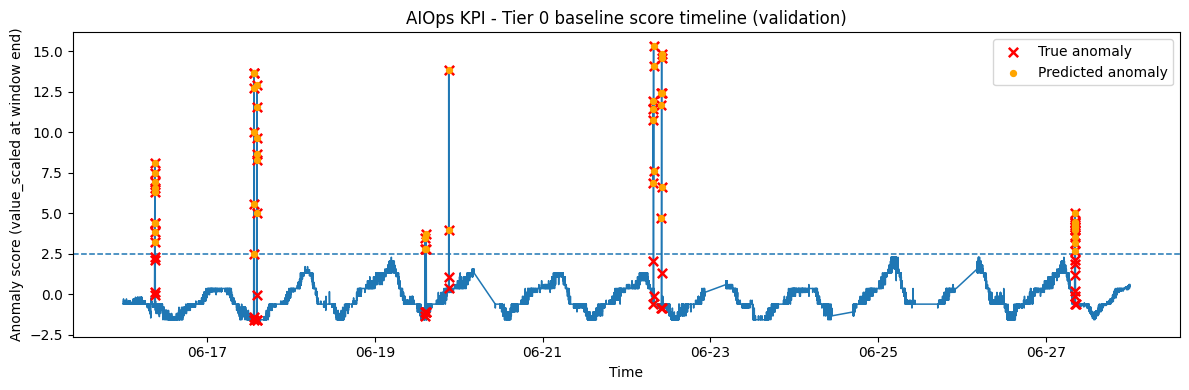

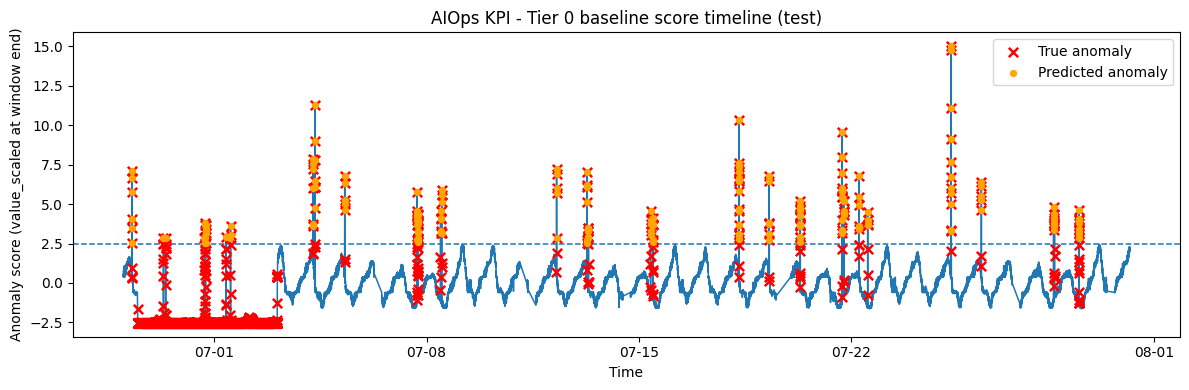

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_score_timeline(pred_df, split_name, threshold_value):
    """Score timeline with clear markers and readable month-day ticks."""
    dfp = pred_df.copy()
    is_true = dfp["is_anomaly"].eq(1)
    is_pred = dfp["pred_is_anomaly"].eq(1)

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(dfp["time"], dfp["anomaly_score"], linewidth=1.1, zorder=1)
    ax.axhline(threshold_value, linestyle="--", linewidth=1.1, zorder=2)

    # Markers on top of the line
    ax.scatter(dfp.loc[is_true, "time"], dfp.loc[is_true, "anomaly_score"],
               marker="x", s=45, linewidths=1.8, color="red", zorder=5, label="True anomaly")
    
    ax.scatter(dfp.loc[is_pred, "time"], dfp.loc[is_pred, "anomaly_score"],
               marker="o", s=18, color="orange", zorder=5, label="Predicted anomaly")

    # Month-day ticks like 06-17, 06-19
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    ax.set_title(f"AIOps KPI - Tier 0 baseline score timeline ({split_name})")
    ax.set_xlabel("Time")
    ax.set_ylabel("Anomaly score (value_scaled at window end)")
    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout()
    return fig

fig_val = plot_score_timeline(val_predictions, "validation", chosen_threshold)
fig_test = plot_score_timeline(test_predictions, "test", chosen_threshold)
plt.show()



### Step 12 - Diagnostic score timelines (validation and test)

These figures visualise the Tier 0 baseline for the selected window length (**L = 360**) using the **window-end `value_scaled`** as the anomaly score and the **validation-selected threshold** (dashed horizontal line).

**How to read the plots**
- The blue line is the anomaly score over time.
- The dashed line is the single decision threshold selected using validation windows only (2.4887 ~ 2.5).
- Red “X” markers show windows whose true label is anomalous (`is_anomaly = 1`).
- Orange markers show windows that the baseline predicts as anomalous (`pred_is_anomaly = 1`).

#### Validation timeline (top)
- Predicted anomalies mostly cluster around periods where the score sharply spikes above the threshold.
- Many true anomaly windows coincide with these spikes, indicating that under validation conditions the threshold captures a meaningful subset of labelled anomalies.
- The threshold behaves conservatively: predictions occur mainly at pronounced peaks rather than broadly across normal fluctuations.

#### Test timeline (bottom)
- The test period shows sustained oscillations and multiple spikes, consistent with a different operating regime relative to validation.
- Many true anomaly windows (red X) occur during extended low-level periods and do not exceed the threshold, so they are not flagged by this baseline.
- Predicted anomalies (orange) appear mostly at higher peaks; the threshold therefore remains conservative (few false positives) but misses large portions of the incident-heavy test regime.

**What this diagnostic supports**
- The plots visually explain the metric pattern already observed: strong precision with low recall on the test split.
- The result is expected for this Tier 0 rule because it relies only on the window-end z-score and a single global threshold; it does not adapt to regime changes or dense incident periods.
- This confirms the rationale for proceeding to stronger baselines (Tier 1 and Tier 2) that learn richer patterns from full windows rather than using only the window end point.


## Step 13 - Prepare a clean results record for Tier 0 (to be saved at the end)


This step prepares the Tier 0 run’s results in a structured form so it can be appended into `all_results.csv` at the end of the notebook.

What is captured here:
- Case identifier and model label (Tier 0 baseline name).
- Window length (L) and the threshold strategy used.
- Validation metrics (the threshold was selected on validation).
- Test metrics (evaluated once, using the same threshold without re-tuning).
- Basic counts to make class imbalance and missed detections explicit.

No files are written in this step. The row is stored in memory and will be saved later.


In [40]:
# Step 13 — Tier 0 results row (kept in memory; saving happens at the end)

validation_window_count = int((val_predictions["split"] == "validation").sum())
test_window_count = int((test_predictions["split"] == "test").sum())

tier0_results_row = pd.DataFrame(
    [
        ("case_study", "aiops_kpi"),
        ("model_name", "tier0_static_zscore_window_end"),
        ("window_length_L", int(window_length)),
        ("threshold_strategy", "validation_f1_maximisation"),
        ("chosen_threshold", float(chosen_threshold)),

        # Threshold-based validation metrics (at chosen threshold)
        ("validation_precision", float(val_precision)),
        ("validation_recall", float(val_recall)),
        ("validation_f1_score", float(val_f1)),
        ("validation_true_positives", int(val_tp)),
        ("validation_false_positives", int(val_fp)),
        ("validation_false_negatives", int(val_fn)),
        ("validation_window_count", validation_window_count),

        # Ranking validation metrics (threshold-free)
        ("validation_auroc", None if validation_auroc is None else float(validation_auroc)),
        ("validation_pr_auc", None if validation_pr_auc is None else float(validation_pr_auc)),

        # Threshold-based test metrics (same threshold; no re-tuning)
        ("test_precision", float(test_precision)),
        ("test_recall", float(test_recall)),
        ("test_f1_score", float(test_f1)),
        ("test_true_positives", int(test_tp)),
        ("test_false_positives", int(test_fp)),
        ("test_false_negatives", int(test_fn)),
        ("test_window_count", test_window_count),

        # Ranking test metrics (threshold-free)
        ("test_auroc", None if test_auroc is None else float(test_auroc)),
        ("test_pr_auc", None if test_pr_auc is None else float(test_pr_auc)),
    ],
    columns=["field", "value"],
)

tier0_results_row


,field,value
0,case_study,aiops_kpi
1,model_name,tier0_static_zscore_window_end
2,window_length_L,360
3,threshold_strategy,validation_f1_maximisation
4,chosen_threshold,2.488696
5,validation_precision,1.0
6,validation_recall,0.64557
7,validation_f1_score,0.784615
8,validation_true_positives,51
9,validation_false_positives,0


## Step 14 - Define standard filenames for Tier 0 artefacts (no saving yet)


This step defines clear, consistent filenames for Tier 0 outputs (predictions, metrics, figures).  
Nothing is written to disk here. The goal is to keep naming consistent so end-of-notebook saving is simple and does not overwrite other outputs.


In [41]:
# Step 14 — Standard artefact names for Tier 0 (used later in the final saving cell)

tier0_tag = f"tier0_static_zscore_window_end_L{int(window_length)}"

tier0_files = {
    "val_predictions_csv": f"{tier0_tag}_validation_predictions.csv",
    "test_predictions_csv": f"{tier0_tag}_test_predictions.csv",
    "val_metrics_csv": f"{tier0_tag}_validation_metrics.csv",
    "test_metrics_csv": f"{tier0_tag}_test_metrics.csv",
    "threshold_summary_csv": f"{tier0_tag}_threshold_summary.csv",
    "figure_val_png": f"{tier0_tag}_score_timeline_validation.png",
    "figure_test_png": f"{tier0_tag}_score_timeline_test.png",
}

pd.DataFrame(list(tier0_files.items()), columns=["artefact", "filename"])


,artefact,filename
0,val_predictions_csv,tier0_static_zscore_window_end_L360_validation...
1,test_predictions_csv,tier0_static_zscore_window_end_L360_test_predi...
2,val_metrics_csv,tier0_static_zscore_window_end_L360_validation...
3,test_metrics_csv,tier0_static_zscore_window_end_L360_test_metri...
4,threshold_summary_csv,tier0_static_zscore_window_end_L360_threshold_...
5,figure_val_png,tier0_static_zscore_window_end_L360_score_time...
6,figure_test_png,tier0_static_zscore_window_end_L360_score_time...


## Step 15 - Create Tier 0 prediction tables to save later (validation and test)


This step prepares the two standard prediction tables that will be saved at the end of the notebook.

Each table contains, for every valid window end time:
- the timestamp (`time`)
- the anomaly score used by the baseline (`anomaly_score`)
- the binary prediction after applying the chosen threshold (`pred_is_anomaly`)
- the true label (`is_anomaly`)
- the split label (`split`)
- the case identifier (`case_study`)

This structure matches the modelling and evaluation charter’s requirement for consistent per-split prediction outputs.


In [42]:
# Step 15 - Standard prediction tables for Tier 0 (kept in memory; saved at the end)

val_predictions_to_save = val_predictions.loc[
    :, ["time", "anomaly_score", "pred_is_anomaly", "is_anomaly", "split", "case_study"]
].copy()

test_predictions_to_save = test_predictions.loc[
    :, ["time", "anomaly_score", "pred_is_anomaly", "is_anomaly", "split", "case_study"]
].copy()

val_predictions_to_save.head()


,time,anomaly_score,pred_is_anomaly,is_anomaly,split,case_study
0,2017-06-16 00:00:00,-0.598357,0,0,validation,aiops_kpi
1,2017-06-16 00:01:00,-0.598357,0,0,validation,aiops_kpi
2,2017-06-16 00:02:00,-0.598357,0,0,validation,aiops_kpi
3,2017-06-16 00:03:00,-0.598357,0,0,validation,aiops_kpi
4,2017-06-16 00:04:00,-0.598357,0,0,validation,aiops_kpi


## Step 16 - Create Tier 0 metrics tables to save later (validation and test)


 This step prepares two small metrics tables for Tier 0 (validation and test) using the same structure.

Keeping metrics in a table format (rather than printed text) makes it easy to:
- save as CSV,
- compare runs later, and
- trace exactly which threshold and window length produced each result.

No saving happens here; these tables remain in memory for the final saving step.


In [43]:
# Step 16 — Metrics tables for Tier 0 (kept in memory; saved at the end)

tier0_validation_metrics = pd.DataFrame(
    [
        ("Precision", round(val_precision, 4)),
        ("Recall", round(val_recall, 4)),
        ("F1 score", round(val_f1, 4)),
        ("AUROC", None if validation_auroc is None else round(float(validation_auroc), 4)),
        ("PR-AUC", None if validation_pr_auc is None else round(float(validation_pr_auc), 4)),
        ("True positives", int(val_tp)),
        ("False positives", int(val_fp)),
        ("False negatives", int(val_fn)),
        ("Window count", int((val_predictions["split"] == "validation").sum())),
    ],
    columns=["Statistic", "Value"],
)

tier0_test_metrics = pd.DataFrame(
    [
        ("Precision", round(test_precision, 4)),
        ("Recall", round(test_recall, 4)),
        ("F1 score", round(test_f1, 4)),
        ("AUROC", None if test_auroc is None else round(float(test_auroc), 4)),
        ("PR-AUC", None if test_pr_auc is None else round(float(test_pr_auc), 4)),
        ("True positives", int(test_tp)),
        ("False positives", int(test_fp)),
        ("False negatives", int(test_fn)),
        ("Window count", int((test_predictions["split"] == "test").sum())),
    ],
    columns=["Statistic", "Value"],
)

tier0_validation_metrics


,Statistic,Value
0,Precision,1.0000
1,Recall,0.6456
2,F1 score,0.7846
3,AUROC,0.8266
4,PR-AUC,0.6764
5,True positives,51.0000
6,False positives,0.0000
7,False negatives,28.0000
8,Window count,15473.0000


In [44]:
tier0_test_metrics

,Statistic,Value
0,Precision,1.0000
1,Recall,0.0274
2,F1 score,0.0533
3,AUROC,0.0412
4,PR-AUC,0.1726
5,True positives,189.0000
6,False positives,0.0000
7,False negatives,6716.0000
8,Window count,44926.0000


## Step 17 - End-of-notebook saving plan (do nothing yet)


This step does not save anything. It only confirms what will be saved at the end and which in-memory objects will be written.

Tier 0 objects ready for end-of-notebook saving:
- `val_predictions_to_save` and `test_predictions_to_save` (prediction tables)
- `tier0_validation_metrics` and `tier0_test_metrics` (metrics tables)
- `tier0_results_row` (single-row results record for `all_results.csv`)
- `fig_val` and `fig_test` (figures stored as variables for saving)

The next step will move into Tier 1 baselines (Isolation Forest and One-Class SVM) using the same windowing outputs already created.


In [45]:
# Step 17 — Quick checklist (no saving yet)

saving_plan = pd.DataFrame(
    [
        ("Predictions (validation)", "val_predictions_to_save"),
        ("Predictions (test)", "test_predictions_to_save"),
        ("Metrics (validation)", "tier0_validation_metrics"),
        ("Metrics (test)", "tier0_test_metrics"),
        ("Results row (for all_results.csv)", "tier0_results_row"),
        ("Figure (validation)", "fig_val"),
        ("Figure (test)", "fig_test"),
    ],
    columns=["Artefact", "In-memory object"],
)

saving_plan


,Artefact,In-memory object
0,Predictions (validation),val_predictions_to_save
1,Predictions (test),test_predictions_to_save
2,Metrics (validation),tier0_validation_metrics
3,Metrics (test),tier0_test_metrics
4,Results row (for all_results.csv),tier0_results_row
5,Figure (validation),fig_val
6,Figure (test),fig_test


## Step 18 - Tier 1 baselines: define tabular window features (shared for IF and OC-SVM)


Tier 1 (Isolation Forest and One-Class SVM) needs a tabular representation of each window.

This step converts each valid window into a small set of summary features computed from `value_scaled`, for example:
- mean, standard deviation
- minimum, maximum
- last value (window end)
- simple trend (difference between last and first)

These features are computed only for valid window end indexes (windows that do not cross time gaps).

Nothing is trained yet in this step. It only creates:
- `X_train`, `X_validation`, `X_test` feature matrices
- matching label vectors for validation/test


In [46]:
# Step 18 — Window feature builder for Tier 1 (tabular baselines)

def build_window_feature_table(df, end_indexes, window_length):
    """
    Build a tabular feature table for each window ending at end_indexes.

    Features are computed from the last `window_length` points of `value_scaled`.
    Windows are assumed to be continuous because end_indexes were created using the continuous-step rule.
    """
    values = df["value_scaled"].to_numpy(float)

    rows = []
    for end_i in end_indexes:
        start_i = end_i - (window_length - 1)
        window = values[start_i : end_i + 1]

        rows.append(
            (
                float(window.mean()),
                float(window.std(ddof=0)),
                float(window.min()),
                float(window.max()),
                float(window[-1]),
                float(window[-1] - window[0]),
            )
        )

    feature_names = [
        "window_mean",
        "window_standard_deviation",
        "window_minimum",
        "window_maximum",
        "window_end_value",
        "window_trend_end_minus_start",
    ]

    return pd.DataFrame(rows, columns=feature_names)

# Build features for all valid windows (same end_indexes already used for Tier 0 scoring)
features_all = build_window_feature_table(df, end_indexes, window_length)

# Align splits and labels at the same window ends
splits_all = df.loc[end_indexes, "split"].to_numpy()
labels_all = df.loc[end_indexes, "is_anomaly"].to_numpy(int)

# Split into train/validation/test
X_train = features_all.loc[splits_all == "train"].reset_index(drop=True)
X_validation = features_all.loc[splits_all == "validation"].reset_index(drop=True)
X_test = features_all.loc[splits_all == "test"].reset_index(drop=True)

y_validation = labels_all[splits_all == "validation"]
y_test = labels_all[splits_all == "test"]

pd.DataFrame(
    [
        ("Train windows", int(len(X_train))),
        ("Validation windows", int(len(X_validation))),
        ("Test windows", int(len(X_test))),
        ("Feature count", int(X_train.shape[1])),
    ],
    columns=["Statistic", "Value"],
)


,Statistic,Value
0,Train windows,56643
1,Validation windows,15473
2,Test windows,44926
3,Feature count,6


#### Step 18 - Tier 1 feature table created for window-based baselines
This step converts each valid **continuous** window (length `L = 360`) into a compact **tabular feature vector** so that Tier 1 classical models (Isolation Forest and One-Class SVM) can be trained and scored.

A total of **56,643 training windows**, **15,473 validation windows**, and **44,926 test windows** were converted into feature rows. Each row contains **6 summary features** computed from the window’s `value_scaled` sequence:
- central tendency and spread (mean, standard deviation),
- range behaviour (minimum, maximum),
- end behaviour (window-end value),
- simple trend (end minus start).

These features reuse the same valid window end indexes created earlier (gap-aware), ensuring that Tier 1 baselines operate on the same window set and remain directly comparable to Tier 0 results.


## Step 19 - Tier 1 baseline: Isolation Forest (train on train only, threshold on validation only)


In [47]:
# Step 19 — Isolation Forest baseline (Tier 1)

from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score

# Train on training windows only (unsupervised)
isolation_forest = IsolationForest(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)
isolation_forest.fit(X_train)

# IsolationForest: score_samples is higher for "more normal" → invert so higher = "more anomalous"
if_val_scores = -isolation_forest.score_samples(X_validation)
if_test_scores = -isolation_forest.score_samples(X_test)

# Threshold chosen on validation only (maximise validation F1)
best_if = best_threshold_by_f1(if_val_scores, y_validation)
chosen_if_threshold = float(best_if["threshold"])

if_val_pred = (if_val_scores >= chosen_if_threshold).astype(int)
if_test_pred = (if_test_scores >= chosen_if_threshold).astype(int)

# Confusion-based metrics at the chosen threshold (uses the helper already defined earlier)
if_val_precision, if_val_recall, if_val_f1, if_val_tp, if_val_fp, if_val_fn = classification_summary(y_validation, if_val_pred)
if_test_precision, if_test_recall, if_test_f1, if_test_tp, if_test_fp, if_test_fn = classification_summary(y_test, if_test_pred)

# Threshold-free ranking metrics (use raw scores; no threshold required)
try:
    if_val_auroc = float(roc_auc_score(y_validation, if_val_scores))
except ValueError:
    if_val_auroc = None  # happens if only one class is present

try:
    if_val_pr_auc = float(average_precision_score(y_validation, if_val_scores))
except ValueError:
    if_val_pr_auc = None

try:
    if_test_auroc = float(roc_auc_score(y_test, if_test_scores))
except ValueError:
    if_test_auroc = None

try:
    if_test_pr_auc = float(average_precision_score(y_test, if_test_scores))
except ValueError:
    if_test_pr_auc = None

# Tables (kept as DataFrames for clean display)
if_threshold_summary = pd.DataFrame(
    [
        ("Threshold strategy", "Validation F1 maximisation"),
        ("Chosen threshold (anomaly_score)", round(chosen_if_threshold, 4)),
        ("Validation precision", round(if_val_precision, 4)),
        ("Validation recall", round(if_val_recall, 4)),
        ("Validation F1 score", round(if_val_f1, 4)),
        ("Validation AUROC", None if if_val_auroc is None else round(if_val_auroc, 4)),
        ("Validation PR-AUC", None if if_val_pr_auc is None else round(if_val_pr_auc, 4)),
    ],
    columns=["Statistic", "Value"],
)

if_test_summary = pd.DataFrame(
    [
        ("Test precision", round(if_test_precision, 4)),
        ("Test recall", round(if_test_recall, 4)),
        ("Test F1 score", round(if_test_f1, 4)),
        ("Test AUROC", None if if_test_auroc is None else round(if_test_auroc, 4)),
        ("Test PR-AUC", None if if_test_pr_auc is None else round(if_test_pr_auc, 4)),
        ("Test true positives", int(if_test_tp)),
        ("Test false positives", int(if_test_fp)),
        ("Test false negatives", int(if_test_fn)),
        ("Test window count", int(len(y_test))),
    ],
    columns=["Statistic", "Value"],
)

if_threshold_summary


,Statistic,Value
0,Threshold strategy,Validation F1 maximisation
1,Chosen threshold (anomaly_score),0.6751
2,Validation precision,0.4928
3,Validation recall,0.4304
4,Validation F1 score,0.4595
5,Validation AUROC,0.9313
6,Validation PR-AUC,0.3867


In [48]:
if_test_summary


,Statistic,Value
0,Test precision,0.2587
1,Test recall,0.0129
2,Test F1 score,0.0246
3,Test AUROC,0.9477
4,Test PR-AUC,0.6494
5,Test true positives,89.0000
6,Test false positives,255.0000
7,Test false negatives,6816.0000
8,Test window count,44926.0000


## Step 19 — Tier 1 baseline results: Isolation Forest

This step reports the **Isolation Forest** baseline on the AIOps KPI window dataset.

Isolation Forest is trained on **training windows only** (unsupervised). A **single decision threshold** is selected using **validation windows only** by maximising the **validation F1 score**. That same threshold is then applied unchanged to the **test** split so test results remain held out.

In addition to threshold-based metrics (precision/recall/F1), **AUROC** and **PR-AUC** are reported using the **raw anomaly scores** (threshold-free ranking performance).

### Validation threshold selection outcome (drives the chosen threshold)

- Threshold strategy: Validation F1 maximisation  
- Chosen threshold (anomaly_score): 0.6751  
- Validation precision: 0.4928  
- Validation recall: 0.4304  
- Validation F1 score: 0.4595  
- Validation AUROC: 0.9313  
- Validation PR-AUC: 0.3867  

These results indicate that the raw scores separate classes well in a ranking sense (high AUROC), while PR-AUC reflects the stricter penalty under class imbalance. The chosen threshold represents the operating point that maximises validation F1.

### Test performance using the same threshold (held-out evaluation)

- Test precision: 0.2587  
- Test recall: 0.0129  
- Test F1 score: 0.0246  
- Test AUROC: 0.9477  
- Test PR-AUC: 0.6494  
- Test true positives: 89  
- Test false positives: 255  
- Test false negatives: 6,816  
- Test window count: 44,926  

On the test split, threshold-based recall is very low at the validation-chosen operating point, meaning many anomaly-labelled windows are not flagged. At the same time, AUROC and PR-AUC remain relatively strong, indicating the anomaly scores still contain useful ranking signal even when a single fixed threshold transfers poorly from validation to the incident-heavy test period.


## Step 19A - Isolation Forest score timeline figures (validation and test)


In [49]:
# Build per-split window end times (aligned to the per-split scores)
is_validation_window = window_split.eq("validation").to_numpy()
is_test_window = window_split.eq("test").to_numpy()

window_time_validation = window_time[is_validation_window].reset_index(drop=True)
window_time_test = window_time[is_test_window].reset_index(drop=True)


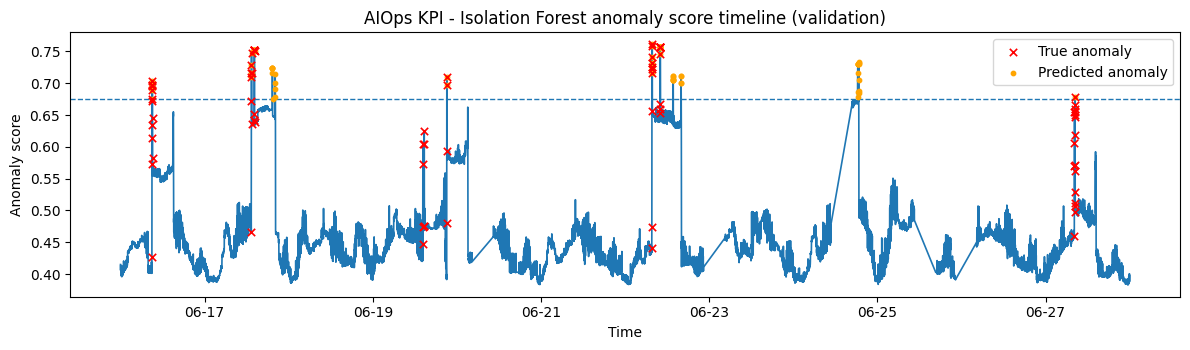

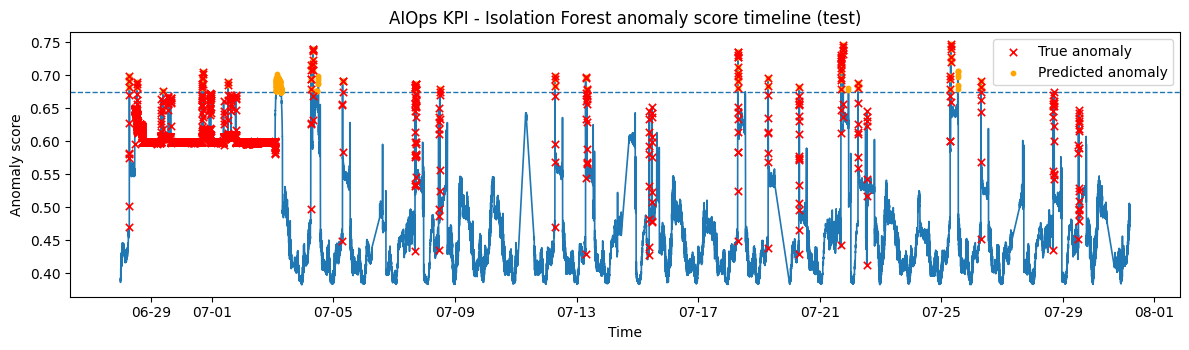

In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_score_timeline(times, scores, true_labels, predicted_labels, threshold, title):
    """Plot anomaly score over time with true/predicted anomaly markers and a threshold line."""
    fig, ax = plt.subplots(figsize=(12, 3.6))

    # Score line
    ax.plot(times, scores, linewidth=1.2, zorder=1)

    # Threshold (chosen on validation only)
    ax.axhline(threshold, linestyle="--", linewidth=1.0, zorder=2)

    # Markers (on top of the line)
    true_mask = (true_labels == 1)
    pred_mask = (predicted_labels == 1)

    ax.scatter(times[true_mask], scores[true_mask], marker="x", s=28, linewidths=1.2,
               color="red", label="True anomaly", zorder=4)
    ax.scatter(times[pred_mask], scores[pred_mask], marker="o", s=10,
               color="orange", label="Predicted anomaly", zorder=3)



    # Date formatting as MM-DD (e.g., 06-17)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Anomaly score")
    ax.legend(loc="upper right", frameon=True)

    fig.tight_layout()
    return fig

# Threshold selected on validation (carry to test unchanged)
if_threshold = float(best_if["threshold"])

# Validation plot (aligned data)
y_validation_windows = y[is_validation_window]
if_validation_fig = plot_score_timeline(
    times=window_time_validation.to_numpy(),
    scores=if_val_scores,
    true_labels=y_validation_windows,
    predicted_labels=if_val_pred,
    threshold=if_threshold,
    title="AIOps KPI - Isolation Forest anomaly score timeline (validation)",
)

# Test plot (aligned data)
y_test_windows = y[is_test_window]
if_test_fig = plot_score_timeline(
    times=window_time_test.to_numpy(),
    scores=if_test_scores,
    true_labels=y_test_windows,
    predicted_labels=if_test_pred,
    threshold=if_threshold,
    title="AIOps KPI - Isolation Forest anomaly score timeline (test)",
)

if_validation_fig, if_test_fig
plt.show()



### Purpose
These figures visualise Isolation Forest **anomaly scores over time** and overlay:
- **true anomaly windows** (red `x`), and
- **predicted anomaly windows** (orange dots),
using the **validation-selected threshold** as a fixed reference line. This provides a drift-aware diagnostic: it shows whether a threshold calibrated on validation transfers sensibly to the test regime.


## Isolation Forest baseline — anomaly score timelines (validation and test)

These figures visualise the **Isolation Forest anomaly score** over time for the AIOps KPI pilot case, using **continuous 360-minute windows** (window-end aligned). The dashed horizontal line is the **decision threshold** selected using the **validation split only** (to prevent leakage). Red **x** markers show **true anomaly labels**, and orange markers show **predicted anomaly windows** (scores above the threshold).

### Validation behaviour (top panel)
On the validation split, the anomaly score shows several clear spikes that occur in the same periods as labelled anomalies. Predicted anomaly markers cluster around these labelled periods, indicating that the Isolation Forest is able to assign higher anomaly scores to some anomalous behaviour under the validation regime. There are also intervals where scores rise without a matching anomaly label, which may reflect **false positives** or **label sparsity** (labels may not capture every unusual pattern in an operational signal).

### Test behaviour (bottom panel)
On the test split, the score pattern changes: the series contains long stretches with elevated scores while labelled anomalies are dense, consistent with the known **incident-heavy test regime** for Case D. The Isolation Forest produces many predicted anomalies in these regions, showing high sensitivity to the incident regime. However, the alignment is not perfect: some labelled anomalies occur below the threshold and some high-score windows may occur without labels. This indicates that a threshold calibrated on validation does not transfer perfectly to the test regime, which is expected under **concept drift / regime shift**.

### Research interpretation (why these plots are included)
These plots provide drift-aware evidence to complement numeric metrics. They show *when* the detector triggers and how score distributions differ between validation and test. This supports the study’s framing of **dynamic business time-series**, where operational regimes change over time and detectors must be evaluated under shifting score distributions. The figures also motivate the next modelling stages (stronger baselines and diffusion-based methods) to test whether they achieve more stable separation and better generalisation across regimes while still using **validation-only threshold selection**.


## Step 20 - Tier 1 Baseline: One-Class SVM (OC-SVM) `nu` selction, test held out


This step fits **One-Class SVM (RBF)** on **scaled training windows only**, selects **nu** using **validation-only thresholding** (best validation F1), and reports **threshold-based metrics (Precision/Recall/F1)** plus **threshold-free ranking metrics (AUROC, PR-AUC)** on both validation and test.


In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import pandas as pd

# --- 1) Scale window features using TRAIN only (prevents leakage) ---
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_validation_scaled = feature_scaler.transform(X_validation)
X_test_scaled = feature_scaler.transform(X_test)

# --- 2) Small nu grid (controls how strict the boundary is) ---
nu_candidates = [0.01, 0.05, 0.10]

def safe_auroc(y_true, scores):
    """Return AUROC if defined; otherwise NaN (e.g., only one class present)."""
    try:
        return float(roc_auc_score(y_true, scores))
    except Exception:
        return float("nan")

def safe_pr_auc(y_true, scores):
    """Return PR-AUC (Average Precision) if defined; otherwise NaN."""
    try:
        return float(average_precision_score(y_true, scores))
    except Exception:
        return float("nan")

rows = []

for nu_value in nu_candidates:
    ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=nu_value)
    ocsvm.fit(X_train_scaled)

    # decision_function: higher = more normal
    # negate so that higher scores mean "more anomalous"
    validation_scores = (-ocsvm.decision_function(X_validation_scaled)).astype(float)
    test_scores = (-ocsvm.decision_function(X_test_scaled)).astype(float)

    # Choose a single threshold on validation only (F1 maximisation)
    best = best_threshold_by_f1(validation_scores, y_validation)
    chosen_threshold = float(best["threshold"])

    # Apply the same threshold to validation and test (no re-tuning)
    validation_pred = (validation_scores >= chosen_threshold).astype(int)
    test_pred = (test_scores >= chosen_threshold).astype(int)

    # Threshold-based metrics (binary predictions)
    val_precision, val_recall, val_f1, _, _, _ = classification_summary(y_validation, validation_pred)
    test_precision, test_recall, test_f1, _, _, _ = classification_summary(y_test, test_pred)

    # Threshold-free metrics (raw scores)
    val_auroc = safe_auroc(y_validation, validation_scores)
    val_pr_auc = safe_pr_auc(y_validation, validation_scores)
    test_auroc = safe_auroc(y_test, test_scores)
    test_pr_auc = safe_pr_auc(y_test, test_scores)

    rows.append(
        (
            float(nu_value),
            round(chosen_threshold, 4),
            round(val_precision, 4),
            round(val_recall, 4),
            round(val_f1, 4),
            round(val_auroc, 4) if np.isfinite(val_auroc) else np.nan,
            round(val_pr_auc, 4) if np.isfinite(val_pr_auc) else np.nan,
            round(test_precision, 4),
            round(test_recall, 4),
            round(test_f1, 4),
            round(test_auroc, 4) if np.isfinite(test_auroc) else np.nan,
            round(test_pr_auc, 4) if np.isfinite(test_pr_auc) else np.nan,
        )
    )

ocsvm_model_selection = pd.DataFrame(
    rows,
    columns=[
        "nu",
        "Best validation threshold",
        "Validation precision",
        "Validation recall",
        "Validation F1 score",
        "Validation AUROC",
        "Validation PR-AUC",
        "Test precision",
        "Test recall",
        "Test F1 score",
        "Test AUROC",
        "Test PR-AUC",
    ],
)

ocsvm_model_selection


,nu,Best validation threshold,Validation precision,Validation recall,Validation F1 score,Validation AUROC,Validation PR-AUC,Test precision,Test recall,Test F1 score,Test AUROC,Test PR-AUC
0,0.01,46.9888,0.5429,0.2405,0.3333,0.8396,0.2488,0.7143,0.0007,0.0014,0.9757,0.7672
1,0.05,322.5879,0.5000,0.2785,0.3577,0.8822,0.2700,0.7500,0.0009,0.0017,0.9755,0.7555
2,0.10,780.9008,0.4898,0.3038,0.3750,0.8940,0.2827,0.6667,0.0009,0.0017,0.9707,0.7230


## Step 20 — Tier 1 Baseline Results: One-Class SVM (validation-thresholded, test held out)

This step evaluates a Tier 1 classical baseline (**One-Class SVM, RBF kernel**) on the AIOps KPI window dataset. In line with the Modelling and Evaluation Charter, the model is trained using **training windows only** (unsupervised learning). For each candidate **nu** value, an anomaly score is produced for validation and test windows, and a **single decision threshold is chosen using validation windows only** by maximising **validation F1 score**. That same threshold is then applied **unchanged** to the test split.

### Model selection setup (what is being varied)
- **Input:** window-level feature vectors, scaled using a **train-fitted StandardScaler** (prevents leakage).
- **Model family:** One-Class SVM (RBF, `gamma="scale"`).
- **Candidate hyperparameter:** `nu ∈ {0.01, 0.05, 0.10}` (controls how strict/tight the boundary is).
- **Thresholding strategy:** **Validation F1 maximisation** (threshold selected on validation only).

### What the results table shows (key patterns)
Across the three `nu` candidates:

- **Validation discrimination looks strong (AUROC ≈ 0.84–0.89),** and **validation PR-AUC increases slightly** as `nu` increases (≈ 0.25 → 0.28).  
  This indicates that the scoring function can rank anomalous windows above normal windows *to some degree* on validation.

- **Validation F1 is still modest (≈ 0.33–0.38).**  
  This indicates that once the score must be converted into a hard decision using a single threshold, the precision/recall trade-off is not strong enough to produce a high F1 on validation.

- **Test recall collapses to near-zero for all candidates (≈ 0.0007–0.0009), producing near-zero test F1 (≈ 0.0014–0.0017).**  
  This means that under the incident-heavy test regime, the threshold calibrated on validation produces **almost no true detections**, even though test precision appears moderate to high (≈ 0.67–0.75) because very few windows are being flagged at all.

- **Test AUROC is very high (≈ 0.97–0.98) and test PR-AUC is also high (≈ 0.72–0.77), despite near-zero recall at the chosen threshold.**  
  This combination suggests that the **ranking quality** of anomaly scores is strong, but the **chosen decision threshold (selected on validation)** does not transfer well into the test regime.

### Interpretation for this case study (why this matters)
Case D contains a **much more anomaly-dense test period** than validation. A threshold that looks sensible on the quieter validation segment can become too conservative on the incident-heavy test segment, causing **severe under-detection**. This is consistent with drift / regime shift effects expected in dynamic business time-series.

### Practical conclusion (what this baseline establishes)
- The OC-SVM baseline shows that **score ranking can remain strong** (high AUROC / PR-AUC), but **threshold transfer across regimes is fragile**.
- This motivates the next planned steps: keep leakage control (train-only training, validation-only thresholding), compare against other baselines (Isolation Forest, then LSTM AE and diffusion) under the same harness, and add drift-aware breakdowns where relevant.


## Step 21 - Select best OC-SVM setting (by validation F1) and prepare standard prediction tables



This step evaluates a **classical unsupervised baseline** (OC-SVM) on the AIOps KPI case using the **standard window representation** (window length `L = 360`). The model is trained on **training windows only** (normal-behaviour modelling), produces an **anomaly score** for each window in validation/test, and then converts scores into binary anomaly decisions using a **threshold selected on validation only** (to avoid test leakage), as specified in the Modelling and Evaluation Charter.


### What was selected
Model selection used the table `ocsvm_model_selection` to choose the best `nu` under the **validation F1 maximisation** strategy.

**Chosen hyperparameter**
- **Chosen `nu`: 0.1**

**Thresholding**
- **Threshold strategy:** Validation F1 maximisation  
- **Chosen threshold (on `anomaly_score`):** 167.8293  
- The threshold was fitted using **validation windows only**, then applied **unchanged** to test windows.


In [52]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, average_precision_score

# --- Column names (define once) ---
SUMMARY_COLS = ["Statistic", "Value"]

# --- 1) Pick best nu from the existing grid table (highest validation F1 score) ---
grid_results = ocsvm_model_selection  # this table already exists in the notebook
best_nu = float(grid_results.sort_values("Validation F1 score", ascending=False).iloc[0]["nu"])

# --- 2) Split window arrays (already created earlier) ---
train_mask = (window_split == "train").to_numpy()
val_mask = (window_split == "validation").to_numpy()
test_mask = (window_split == "test").to_numpy()

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

t_val = window_time[val_mask].reset_index(drop=True)
t_test = window_time[test_mask].reset_index(drop=True)

# --- 3) Scale features using train only (prevents leakage) ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# --- 4) Train OC-SVM on training windows only (unsupervised) ---
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=best_nu)
ocsvm.fit(X_train_s)

# --- 5) Scores (higher = more anomalous) ---
val_scores = (-ocsvm.decision_function(X_val_s)).astype(float)
test_scores = (-ocsvm.decision_function(X_test_s)).astype(float)

# --- 6) Threshold from validation only (maximise validation F1), then apply to test ---
best = best_threshold_by_f1(val_scores, y_val)
chosen_threshold = float(best["threshold"])

val_pred = (val_scores >= chosen_threshold).astype(int)
test_pred = (test_scores >= chosen_threshold).astype(int)

# --- 7) Standard prediction tables (validation + test) ---
ocsvm_val_predictions = pd.DataFrame(
    {
        "time": t_val,
        "anomaly_score": val_scores,
        "pred_is_anomaly": val_pred,
        "is_anomaly": y_val.astype(int),
        "split": "validation",
        "case_study": "aiops_kpi",
    }
)

ocsvm_test_predictions = pd.DataFrame(
    {
        "time": t_test,
        "anomaly_score": test_scores,
        "pred_is_anomaly": test_pred,
        "is_anomaly": y_test.astype(int),
        "split": "test",
        "case_study": "aiops_kpi",
    }
)

# --- 8) Metric helpers (binary metrics + AUROC/PR-AUC from scores) ---
def _binary_metrics(y_true, y_hat):
    y_true = y_true.astype(int)
    y_hat = y_hat.astype(int)
    tp = int(((y_true == 1) & (y_hat == 1)).sum())
    fp = int(((y_true == 0) & (y_hat == 1)).sum())
    fn = int(((y_true == 1) & (y_hat == 0)).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return precision, recall, f1_score, tp, fp, fn

def _auc_metrics(y_true, scores):
    # If y_true has only one class, AUROC/PR-AUC are undefined; return NaN.
    if len(pd.unique(y_true.astype(int))) < 2:
        return float("nan"), float("nan")
    return float(roc_auc_score(y_true, scores)), float(average_precision_score(y_true, scores))

val_precision, val_recall, val_f1, val_tp, val_fp, val_fn = _binary_metrics(y_val, val_pred)
test_precision, test_recall, test_f1, test_tp, test_fp, test_fn = _binary_metrics(y_test, test_pred)

val_auroc, val_prauc = _auc_metrics(y_val, val_scores)
test_auroc, test_prauc = _auc_metrics(y_test, test_scores)

# --- 9) Summary tables (2-tuple pattern) ---
ocsvm_threshold_summary = pd.DataFrame(
    [
        ("Chosen nu", round(best_nu, 4)),
        ("Threshold strategy", "Validation F1 maximisation"),
        ("Chosen threshold (anomaly_score)", round(chosen_threshold, 4)),
        ("Validation precision", round(val_precision, 4)),
        ("Validation recall", round(val_recall, 4)),
        ("Validation F1 score", round(val_f1, 4)),
        ("Validation AUROC", round(val_auroc, 4) if pd.notna(val_auroc) else float("nan")),
        ("Validation PR-AUC", round(val_prauc, 4) if pd.notna(val_prauc) else float("nan")),
        ("Validation window count", int(val_mask.sum())),
    ],
    columns=SUMMARY_COLS,
)

ocsvm_test_summary = pd.DataFrame(
    [
        ("Test precision", round(test_precision, 4)),
        ("Test recall", round(test_recall, 4)),
        ("Test F1 score", round(test_f1, 4)),
        ("Test AUROC", round(test_auroc, 4) if pd.notna(test_auroc) else float("nan")),
        ("Test PR-AUC", round(test_prauc, 4) if pd.notna(test_prauc) else float("nan")),
        ("Test true positives", int(test_tp)),
        ("Test false positives", int(test_fp)),
        ("Test false negatives", int(test_fn)),
        ("Test window count", int(test_mask.sum())),
    ],
    columns=SUMMARY_COLS,
)

ocsvm_threshold_summary


,Statistic,Value
0,Chosen nu,0.1
1,Threshold strategy,Validation F1 maximisation
2,Chosen threshold (anomaly_score),167.8293
3,Validation precision,0.0308
4,Validation recall,0.4051
5,Validation F1 score,0.0573
6,Validation AUROC,0.7573
7,Validation PR-AUC,0.0183
8,Validation window count,15473


In [53]:
ocsvm_test_summary

,Statistic,Value
0,Test precision,0.7265
1,Test recall,0.9445
2,Test F1 score,0.8213
3,Test AUROC,0.9782
4,Test PR-AUC,0.8475
5,Test true positives,6522.0000
6,Test false positives,2455.0000
7,Test false negatives,383.0000
8,Test window count,44926.0000


## Step 21 — Tier 1 Baseline Results: One-Class SVM (validation-thresholded, test held out)

This step reports the **One-Class SVM (OC-SVM)** baseline on the AIOps KPI window dataset. The pipeline follows the Modelling and Evaluation Charter: the model is trained using **training windows only** (unsupervised), a **single decision threshold** is selected using **validation windows only**, and that same threshold is applied unchanged to the **test** split.

### Model selection and scoring setup
- **Selected hyperparameter:** `nu = 0.10` (selected from the candidate grid using validation F1 as the selection signal).
- **Anomaly score definition:** `-decision_function(...)` so that **higher scores mean more anomalous**.
- **Threshold strategy:** **validation F1 maximisation** (threshold chosen only on validation scores).

---

## Validation results (threshold chosen here)

- **Chosen threshold (anomaly_score):** 167.8293  
- **Validation precision:** 0.0308  
- **Validation recall:** 0.4051  
- **Validation F1 score:** 0.0573  
- **Validation AUROC:** 0.7573  
- **Validation PR-AUC:** 0.0183  
- **Validation window count:** 15,473  

**Interpretation (validation):**
- Precision is extremely low, indicating many false alarms at the selected threshold, which collapses F1.
- Recall is moderate, meaning some labelled anomalies are detected, but the false positive rate dominates the classification outcome.
- AUROC suggests the scores have some ranking separation ability, but PR-AUC is very low, which is consistent with an imbalanced setting where precision is fragile.

---

## Test results (same threshold transferred; no re-tuning)

- **Test precision:** 0.7265  
- **Test recall:** 0.9445  
- **Test F1 score:** 0.8213  
- **Test AUROC:** 0.9782  
- **Test PR-AUC:** 0.8475  
- **Test true positives:** 6,522  
- **Test false positives:** 2,455  
- **Test false negatives:** 383  
- **Test window count:** 44,926  

**Interpretation (test):**
- Test performance is strong: high precision and very high recall produce a high F1 score.
- AUROC and PR-AUC indicate that the OC-SVM scores separate anomaly-labelled vs normal windows very effectively in the test regime.

---

## Key takeaway for this case study

The strong contrast between validation and test behaviour is useful evidence that **the validation and test regimes differ substantially** in this KPI (distribution shift and/or change in anomaly structure). This remains charter-consistent because threshold selection was still performed on validation only and test evaluation used the unchanged threshold. This contrast motivates the next phase additions: **drift-aware breakdowns** (e.g., incident vs non-incident segments) and additional baselines for comparison under the same leakage-controlled protocol.


## Step 22 - OC-SVM anomaly score timelines (validation and test)


This step plots the OC-SVM **anomaly score over time** for the **validation** and **test** splits using the same window-end alignment as earlier steps. The **decision threshold** is the value selected on the validation split (validation F1 maximisation) and is shown as a dashed horizontal line.


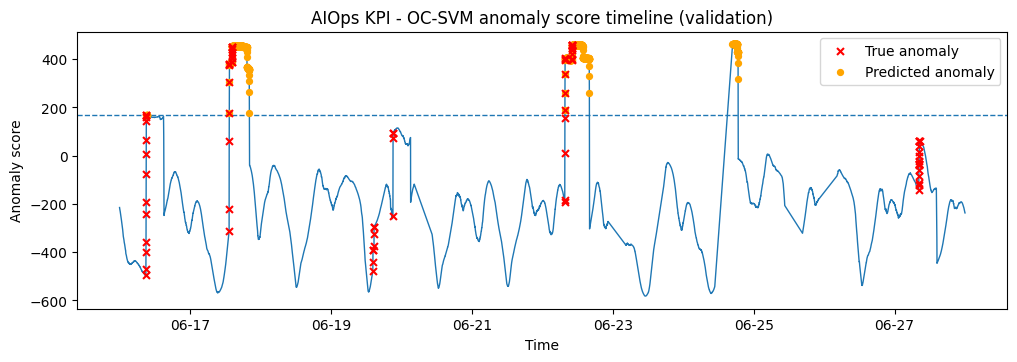

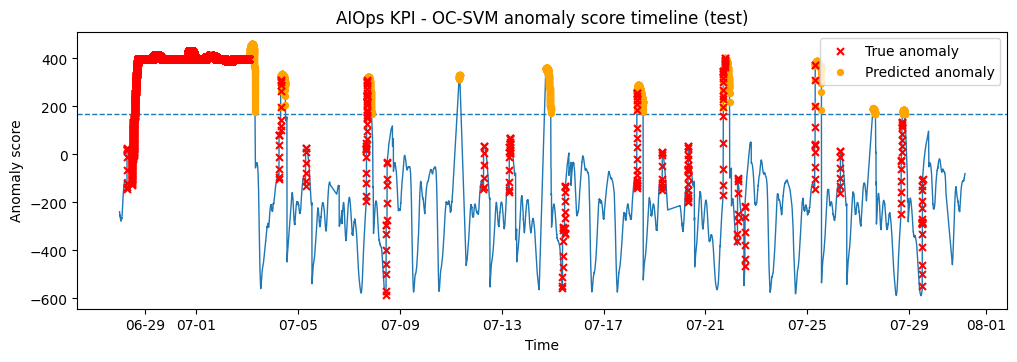

In [56]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# --- Assumes these already exist ---
# window_time, window_split (aligned to all windows)
# y (labels aligned to all windows)
# ocsvm_val_scores, ocsvm_test_scores (scores for validation/test windows)
# chosen_threshold (float, selected on validation only)

# 1) Pull matching window-end timestamps + labels for validation/test
is_validation = (window_split == "validation").to_numpy()
is_test = (window_split == "test").to_numpy()

val_time = window_time[is_validation].reset_index(drop=True)
test_time = window_time[is_test].reset_index(drop=True)

y_validation = y[is_validation]
y_test = y[is_test]

ocsvm_val_scores = val_scores
ocsvm_test_scores = test_scores

# 2) Safety checks: score arrays must align with timestamps
if len(val_time) != len(ocsvm_val_scores):
    raise ValueError(f"Validation timestamps ({len(val_time)}) do not match OC-SVM validation scores ({len(ocsvm_val_scores)}).")
if len(test_time) != len(ocsvm_test_scores):
    raise ValueError(f"Test timestamps ({len(test_time)}) do not match OC-SVM test scores ({len(test_time)}) ({len(ocsvm_test_scores)}).")

# 3) Apply the validation-chosen threshold to create predicted anomaly flags
ocsvm_val_pred = (ocsvm_val_scores >= chosen_threshold).astype(int)
ocsvm_test_pred = (ocsvm_test_scores >= chosen_threshold).astype(int)

# 4) Helper: consistent timeline plot formatting
def plot_score_timeline(time_values, scores, true_labels, pred_labels, threshold, title):
    """Plot anomaly score timeline with true (red X) and predicted (orange dot) markers."""
    fig, ax = plt.subplots(figsize=(12, 3.6))

    # Score line
    ax.plot(time_values, scores, linewidth=1)

    # Threshold line
    ax.axhline(threshold, linestyle="--", linewidth=1)

    # True anomaly markers (red X)
    true_idx = (true_labels == 1)
    ax.scatter(
        time_values[true_idx], scores[true_idx],
        marker="x", color= "red", s=25, zorder=4, label="True anomaly"
    )

    # Predicted anomaly markers (orange dots)
    pred_idx = (pred_labels == 1)
    ax.scatter(
        time_values[pred_idx], scores[pred_idx], color="orange",
        s=18, zorder=3, label="Predicted anomaly"
    )

    # Axes formatting
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Anomaly score")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.tick_params(axis="x", rotation=0)
    ax.legend(loc="upper right")

    plt.show()
    return fig

# 5) Create and store figures (for end-of-notebook saving)
ocsvm_validation_fig = plot_score_timeline(
    val_time, ocsvm_val_scores, y_validation, ocsvm_val_pred, chosen_threshold,
    "AIOps KPI - OC-SVM anomaly score timeline (validation)"
)

ocsvm_test_fig = plot_score_timeline(
    test_time, ocsvm_test_scores, y_test, ocsvm_test_pred, chosen_threshold,
    "AIOps KPI - OC-SVM anomaly score timeline (test)"
)


### OC-SVM baseline score timelines (validation and test)

These figures show the **OC-SVM anomaly score** over time for the **AIOps KPI pilot case**, using the locked **window length L = 360** and a **single decision threshold chosen on the validation split only** (dashed line). This follows the charter’s leakage-control rule: the threshold is calibrated on validation and then applied unchanged to test.

**How to read the plot**

- The **blue line** is the anomaly score (higher means “more anomalous”).
- **Red X markers** show timestamps/windows that are **truly labelled as anomalies**.
- **Orange dots** show windows the model **predicts as anomalous** after applying the validation-chosen threshold.
- The dashed horizontal line is the **fixed threshold**.

---

#### Validation behaviour

On the validation segment, many of the highest score spikes align with clusters of true anomaly labels. The predicted anomaly markers tend to appear on the same high-score regions, indicating that OC-SVM is successfully learning a boundary around “normal” window patterns and flagging windows that deviate strongly from that learned region.

This validation plot is also useful as a calibration check: because the threshold is chosen here, it is expected that the predicted anomaly density will look “reasonable” on validation (it is the split used to tune the decision rule).

---

#### Test behaviour and drift/incident structure

On the test segment, there is a visibly different operating regime compared with validation:

- There is a **dense block of true anomalies early in the test period** (a clear incident-heavy region).
- During this region, the OC-SVM scores frequently sit above the threshold and the model produces a high concentration of predicted anomalies, which is consistent with the case design where the test split contains the main incident regime.

Across the remainder of the test period, predicted anomalies continue to occur around score peaks, and many coincide with true anomaly markers. At the same time, there are also predicted anomalies that do not overlap with true labels, which is expected in this dataset because the anomaly density and behaviour change over time and the OC-SVM decision boundary is learned from training windows only.

---

#### What this contributes to the research narrative

These plots provide drift-aware evidence that a classical unsupervised baseline (OC-SVM):

- can generate **interpretable anomaly scores** that rise sharply during incident-like behaviour,
- can transfer a **validation-calibrated threshold** into the test incident regime without retuning, and
- provides a strong comparison point for later diffusion-based models, which will be evaluated under the same windowing rules, the same split design, and the same validation-only thresholding principle.

In the context of the dissertation, this supports the methodological argument that evaluation must be **regime-aware**: even with consistent preprocessing and strict chronology, the incident-heavy test period represents a different operating condition, and models are assessed on whether they remain effective under that shift.


## Step 23 - End-of-notebook results logging and saving

### Purpose
This step records the baseline outcomes from this notebook in a single, appendable **results-level table** (`all_results.csv`) so that results from later models (and later case studies) can be stacked into one comparable view. This is the start of systematic results logging discussed in the planning notes (results-level stacking).


In [60]:
from pathlib import Path
from datetime import datetime
import pandas as pd

# --- Project paths (notebook is in masters/notebooks/) ---
project_root = Path.cwd().parent

runs_root = project_root / "results" / "aiops_kpi" / "runs"
runs_root.mkdir(parents=True, exist_ok=True)

# Reuse an existing run_id if already defined (prevents accidental new folders)
if "run_id" not in globals():
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

run_dir = runs_root / run_id

figures_dir = run_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Global results file (cross-case, cross-model)
all_results_path = project_root / "results" / "all_results.csv"
all_results_path.parent.mkdir(parents=True, exist_ok=True)


# --- Helper to read values from 2-column summary tables (Statistic, Value) ---
_MISSING = object()

def get_stat(summary_df: pd.DataFrame, accepted_names, default=_MISSING):
    """
    Returns the Value for the first matching Statistic name.
    If default is provided, returns default when no match is found.
    """
    for name in accepted_names:
        match = summary_df.loc[summary_df["Statistic"].eq(name), "Value"]
        if len(match):
            return match.iloc[0]
    if default is _MISSING:
        raise KeyError(f"None of these Statistic names were found: {accepted_names}")
    return default


def build_results_row(case_study, model_name, window_length_L, threshold_summary, test_summary, extra=None):
    """
    Builds one flat row for all_results.csv using existing summary tables.
    Includes AUROC and PR-AUC if present in the summary tables (otherwise saves None).
    """
    row = {
        "run_id": str(run_id),
        "case_study": str(case_study),
        "model_name": str(model_name),
        "window_length_L": int(window_length_L),

        "threshold_strategy": str(get_stat(threshold_summary, ["Threshold strategy"])),
        "chosen_threshold": float(get_stat(
            threshold_summary,
            ["Chosen threshold (anomaly_score)", "Chosen threshold (value_scaled)", "Chosen threshold (value_scaled) "],
        )),

        "validation_precision": float(get_stat(threshold_summary, ["Validation precision"])),
        "validation_recall": float(get_stat(threshold_summary, ["Validation recall"])),
        "validation_f1_score": float(get_stat(threshold_summary, ["Validation F1 score", "Validation F1 score "])),
        "validation_window_count": (
            int(get_stat(threshold_summary, ["Validation window count", "Validation windows"], default=None))
            if get_stat(threshold_summary, ["Validation window count", "Validation windows"], default=None) is not None
            else None
        ),

        # Optional (will be populated after AUROC/PR-AUC are added to the metric tables)
        "validation_auroc": get_stat(threshold_summary, ["Validation AUROC", "Validation ROC-AUC"], default=None),
        "validation_pr_auc": get_stat(threshold_summary, ["Validation PR-AUC", "Validation PR AUC"], default=None),

        "test_precision": float(get_stat(test_summary, ["Test precision"])),
        "test_recall": float(get_stat(test_summary, ["Test recall"])),
        "test_f1_score": float(get_stat(test_summary, ["Test F1 score"])),
        "test_true_positives": int(get_stat(test_summary, ["Test true positives"])),
        "test_false_positives": int(get_stat(test_summary, ["Test false positives"])),
        "test_false_negatives": int(get_stat(test_summary, ["Test false negatives"])),
        "test_window_count": int(get_stat(test_summary, ["Test window count"])),

        # Optional (will be populated after AUROC/PR-AUC are added to the metric tables)
        "test_auroc": get_stat(test_summary, ["Test AUROC", "Test ROC-AUC"], default=None),
        "test_pr_auc": get_stat(test_summary, ["Test PR-AUC", "Test PR AUC"], default=None),
    }

    if extra:
        row.update(extra)

    return row


# --- 1) Build rows from the models already run in this notebook ---
results_rows = [
    build_results_row(
        case_study="aiops_kpi",
        model_name="tier0_static_window_end_rule",
        window_length_L=int(window_length),
        threshold_summary=threshold_summary,
        #threshold_summary=tier0_threshold_summary,
        #test_summary=tier0_test_summary,
        test_summary=test_summary,
        extra={"score_definition": "value_scaled at window end"},
    ),
    build_results_row(
        case_study="aiops_kpi",
        model_name="isolation_forest",
        window_length_L=int(window_length),
        threshold_summary=if_threshold_summary,
        test_summary=if_test_summary,
        extra={"if_n_estimators": 200, "if_random_state": 42},
    ),
    build_results_row(
        case_study="aiops_kpi",
        model_name="ocsvm_rbf",
        window_length_L=int(window_length),
        threshold_summary=ocsvm_threshold_summary,
        test_summary=ocsvm_test_summary,
        extra={
            "ocsvm_kernel": "rbf",
            "ocsvm_gamma": "scale",
            "ocsvm_nu": float(get_stat(ocsvm_threshold_summary, ["Chosen nu"])),
        },
    ),
]

results_to_append = pd.DataFrame(results_rows)

# --- 2) Append into all_results.csv (or create it) and de-duplicate by run+case+model ---
existing = pd.read_csv(all_results_path) if all_results_path.exists() else pd.DataFrame()
combined = pd.concat([existing, results_to_append], ignore_index=True) if len(existing) else results_to_append.copy()

combined = combined.drop_duplicates(subset=["run_id", "case_study", "model_name"], keep="last")
combined.to_csv(all_results_path, index=False)

# --- 3) Save figures (if the figure variables exist) into this run folder ---
figures_to_save = [
    ("tier0_validation_timeline.png", "fig_val"),
    ("tier0_test_timeline.png", "fig_test"),
    ("if_validation_timeline.png", "if_validation_fig"),
    ("if_test_timeline.png", "if_test_fig"),
    ("ocsvm_validation_timeline.png", "ocsvm_validation_fig"),
    ("ocsvm_test_timeline.png", "ocsvm_test_fig"),
    
]

for filename, fig_var in figures_to_save:
    if fig_var in globals() and globals()[fig_var] is not None:
        globals()[fig_var].savefig(figures_dir / filename, bbox_inches="tight")

# --- 4) Quick confirmation output ---
saving_summary = pd.DataFrame(
    [
        ("Run id", str(run_id)),
        ("Run folder", str(run_dir)),
        ("Figures folder", str(figures_dir)),
        ("all_results.csv", str(all_results_path)),
        ("Rows appended this run", int(len(results_to_append))),
        ("Total rows in all_results.csv", int(len(combined))),
    ],
    columns=["Statistic", "Value"],
)

saving_summary


,Statistic,Value
0,Run id,20260108_170724
1,Run folder,/Users/nandipha/Desktop/masters/results/aiops_...
2,Figures folder,/Users/nandipha/Desktop/masters/results/aiops_...
3,all_results.csv,/Users/nandipha/Desktop/masters/results/all_re...
4,Rows appended this run,3
5,Total rows in all_results.csv,3


In [67]:
from pathlib import Path

base = Path.home() / "Library" / "Jupyter" / "nbconvert" / "templates" / "landscape_wrap"
base.mkdir(parents=True, exist_ok=True)

# conf.json
(base / "conf.json").write_text(
    '{\n  "base_template": "lab"\n}\n',
    encoding="utf-8"
)

# index.html.j2 (forces landscape + wrapping for print)
(base / "index.html.j2").write_text(
    """{%- extends 'lab/index.html.j2' -%}

{% block extra_css %}
<style>
@media print {
  @page { size: A4 landscape; margin: 10mm; }

    /* Main document text (Markdown, headings, paragraphs, lists) */
  body {
    font-size: 12pt !important;   /* ← increase this */
    line-height: 1.35 !important;
  }

   /* Headings (optional, adjust to taste) */
 /* h1 { font-size: 20pt !important; } */
 /* h2 { font-size: 16pt !important; } */
 /* h3 { font-size: 14pt !important; } */
 /* h4 { font-size: 12.5pt !important; } */

  /* Code wrapping */
  pre, code { font-size: 10pt !important; line-height: 1.15 !important; }
  pre {
    white-space: pre-wrap !important;
    word-break: break-word !important;
    overflow-wrap: anywhere !important;
  }

  /* DataFrame tables */
  table.dataframe { font-size: 10pt !important; max-width: 100% !important; }
  th, td {
    white-space: normal !important;
    word-break: break-word !important;
    overflow-wrap: anywhere !important;
  }
}
</style>
{% endblock extra_css %}
""",
    encoding="utf-8"
)

print("Template created at:", base)
print("Files:", [p.name for p in base.iterdir()])

Template created at: /Users/nandipha/Library/Jupyter/nbconvert/templates/landscape_wrap
Files: ['conf.json', 'index.html.j2']


In [68]:
import sys
!mkdir -p exports
!{sys.executable} -m nbconvert --to html --template landscape_wrap "03_baselines_aiops_kpiv2.ipynb" --output-dir "exports"


[NbConvertApp] Converting notebook 03_baselines_aiops_kpiv2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1292705 bytes to exports/03_baselines_aiops_kpiv2.html


In [70]:
from pathlib import Path
from playwright.async_api import async_playwright

html_path = Path("exports/03_baselines_aiops_kpiv2.html").resolve()
pdf_path  = Path("exports/03_baselines_aiops_kpiv2_landscape.pdf").resolve()

async def html_to_pdf():
    async with async_playwright() as p:
        browser = await p.chromium.launch()
        page = await browser.new_page()
        await page.goto(html_path.as_uri(), wait_until="networkidle")
        await page.pdf(
            path=str(pdf_path),
            format="A4",
            landscape=True,
            print_background=True,
            prefer_css_page_size=True,
            margin={"top":"10mm","right":"10mm","bottom":"10mm","left":"10mm"},
        )
        await browser.close()

await html_to_pdf()
print("Wrote:", pdf_path)


Wrote: /Users/nandipha/Desktop/masters/notebooks/exports/03_baselines_aiops_kpiv2_landscape.pdf
